#### Mounting to google drive to acccess the data set and required files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### 1. Importing required libraries

In [ ]:
import requests
import numpy as np
import pandas as pd
import holidays
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit,RandomizedSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

#### 2. Importing uber traffic dataset and formatting date column in the dataset

In [ ]:
traffic_data=pd.read_csv('/content/drive/MyDrive/uber_traffic_data.csv')
traffic_data.head()

,DateTime,Junction,Vehicles,ID
0,01/11/15 0:00,1,15,20151101001
1,01/11/15 1:00,1,13,20151101011
2,01/11/15 2:00,1,10,20151101021
3,01/11/15 3:00,1,7,20151101031
4,01/11/15 4:00,1,9,20151101041


In [ ]:
traffic_data['DateTime'] = pd.to_datetime(traffic_data['DateTime'], format='%d/%m/%y %H:%M')

In [ ]:
traffic_data.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


#### 3. Fetching weather data and holiday data for Hyderabad city in Telangana state, India

In [ ]:
lat, lon = 17.3850, 78.4867
start_date = "2015-11-01"
end_date = "2017-06-30"

url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&hourly=temperature_2m,precipitation,rain,snowfall,relative_humidity_2m,wind_speed_10m&timezone=auto"
response = requests.get(url).json()

weather_df = pd.DataFrame(response['hourly'])
weather_df['time'] = pd.to_datetime(weather_df['time'])
print(weather_df.head())

                 time  temperature_2m  precipitation  rain  snowfall  \
0 2015-11-01 00:00:00            23.1            0.0   0.0       0.0   
1 2015-11-01 01:00:00            22.4            0.0   0.0       0.0   
2 2015-11-01 02:00:00            21.6            0.0   0.0       0.0   
3 2015-11-01 03:00:00            21.2            0.0   0.0       0.0   
4 2015-11-01 04:00:00            20.9            0.0   0.0       0.0   

   relative_humidity_2m  wind_speed_10m  
0                    73             5.4  
1                    78             5.8  
2                    82             5.3  
3                    83             5.6  
4                    84             7.1  


In [ ]:
df=traffic_data.copy()

In [ ]:
# indexing helpers
df['date_str'] = df['DateTime'].dt.strftime('%Y-%m-%d')
df['hour_only'] = df['DateTime'].dt.hour
df['day_of_week'] = df['DateTime'].dt.dayofweek
df['month']=df['DateTime'].dt.month
df['is_weekend']=df['day_of_week'].apply(lambda x:1 if x>4 else 0)


ts_holidays = holidays.India(years=[2015, 2016, 2017], state='TS')
df['is_holiday']=df['DateTime'].dt.date.apply(lambda x:1 if x in ts_holidays else 0
                                              )

# FUNCTION TO DYNAMICALLY FIND THE MAX-TRAFFIC JUNCTION FOR AN EVENT
def get_max_traffic_junction(dataframe, start_date, end_date):

    event_days_df = dataframe[
        (dataframe['date_str'] >= start_date) &
        (dataframe['date_str'] <= end_date)
    ]

    if not event_days_df.empty:
        max_junction = event_days_df.groupby('Junction')['Vehicles'].max().idxmax()
        return max_junction
    else:
        return 1

# 19th Children's Film Festival (Nov 14 to Nov 20, 2015)
fest_start, fest_end = '2015-11-14', '2015-11-20'
max_fest_junc = get_max_traffic_junction(df, fest_start, fest_end)

fest_mask = (df['date_str'] >= fest_start) & (df['date_str'] <= fest_end) & \
            (df['hour_only'] >= 9) & (df['hour_only'] <= 21) & \
            (df['Junction'] == max_fest_junc)
df.loc[fest_mask, 'is_festival'] = 1


# SkyFest & Sunburn Gachibowli Stadium 2015
concert15_start, concert15_end = '2015-12-23', '2015-12-27'
max_c15_junc = get_max_traffic_junction(df, concert15_start, concert15_end)

concert_15_mask = (df['date_str'] >= concert15_start) & (df['date_str'] <= concert15_end) & \
                  (df['hour_only'] >= 16) & (df['hour_only'] <= 23) & \
                  (df['Junction'] == max_c15_junc)
df.loc[concert_15_mask, 'is_concert'] = 1
# Sunburn Arena with Martin Garrix @ HITEX (Nov 12, 2016)
concert16_date = '2016-11-12'
max_c16_junc = get_max_traffic_junction(df, concert16_date, concert16_date)

concert_16_mask = (df['date_str'] == concert16_date) & \
                  (df['hour_only'] >= 15) & (df['hour_only'] <= 23) & \
                  (df['Junction'] == max_c16_junc)
df.loc[concert_16_mask, 'is_concert'] = 1


# SPORTS EVENTS (IPL T20 Matches at Uppal Stadium)
ipl_2016_dates = ['2016-04-16', '2016-04-18', '2016-04-23', '2016-04-26', '2016-04-30', '2016-05-06', '2016-05-12']
ipl_2017_dates = ['2017-04-05', '2017-04-09', '2017-04-17', '2017-04-19', '2017-04-30', '2017-05-06', '2017-05-08']
all_ipl_dates = ipl_2016_dates + ipl_2017_dates

# Find which junction consistently handles the highest peak traffic during match months
max_sports_junc = get_max_traffic_junction(df, '2016-04-01', '2017-05-31')

sports_mask = (df['date_str'].isin(all_ipl_dates)) & \
              (df['hour_only'] >= 16) & (df['hour_only'] <= 23) & \
              (df['Junction'] == max_sports_junc)
df.loc[sports_mask, 'is_sports_event'] = 1


dates = [
    '2016-01-18', '2016-01-25',  # Core Chalo HCU mobilization spikes
    '2017-04-17',                 # Satyagraha March near Tank Bund
    '2017-05-12',                 # State Assembly / Gun Park Silent Protest
    '2017-05-15'                  # Major Chalo Indira Park / Dharna Chowk Blockade
]

# Identify the highest bottleneck impact node across the historic protest window
max_demo_junc = get_max_traffic_junction(df, '2016-01-01', '2017-05-31')

demo_mask = (df['date_str'].isin(dates)) & \
            (df['hour_only'] >= 10) & (df['hour_only'] <= 17) & \
            (df['Junction'] == max_demo_junc)
df.loc[demo_mask, 'is_public_demonstration'] = 1

# Drop the temporary calculation columns
df = df.drop(columns=['date_str'])

In [ ]:
df.head()

,DateTime,Junction,Vehicles,ID,hour_only,day_of_week,month,is_weekend,is_holiday,is_festival,is_concert,is_sports_event,is_public_demonstration
0,2015-11-01 00:00:00,1,15,20151101001,0,6,11,1,0,NaN,NaN,NaN,NaN
1,2015-11-01 01:00:00,1,13,20151101011,1,6,11,1,0,NaN,NaN,NaN,NaN
2,2015-11-01 02:00:00,1,10,20151101021,2,6,11,1,0,NaN,NaN,NaN,NaN
3,2015-11-01 03:00:00,1,7,20151101031,3,6,11,1,0,NaN,NaN,NaN,NaN
4,2015-11-01 04:00:00,1,9,20151101041,4,6,11,1,0,NaN,NaN,NaN,NaN


#### 4. Merging weather,holiday and traffic data

In [ ]:
merged_df=pd.merge(df,weather_df,left_on='DateTime', right_on='time')

In [ ]:
merged_df.head()

,DateTime,Junction,Vehicles,ID,hour_only,day_of_week,month,is_weekend,is_holiday,is_festival,is_concert,is_sports_event,is_public_demonstration,time,temperature_2m,precipitation,rain,snowfall,relative_humidity_2m,wind_speed_10m
0,2015-11-01 00:00:00,1,15,20151101001,0,6,11,1,0,NaN,NaN,NaN,NaN,2015-11-01 00:00:00,23.1,0.0,0.0,0.0,73,5.4
1,2015-11-01 01:00:00,1,13,20151101011,1,6,11,1,0,NaN,NaN,NaN,NaN,2015-11-01 01:00:00,22.4,0.0,0.0,0.0,78,5.8
2,2015-11-01 02:00:00,1,10,20151101021,2,6,11,1,0,NaN,NaN,NaN,NaN,2015-11-01 02:00:00,21.6,0.0,0.0,0.0,82,5.3
3,2015-11-01 03:00:00,1,7,20151101031,3,6,11,1,0,NaN,NaN,NaN,NaN,2015-11-01 03:00:00,21.2,0.0,0.0,0.0,83,5.6
4,2015-11-01 04:00:00,1,9,20151101041,4,6,11,1,0,NaN,NaN,NaN,NaN,2015-11-01 04:00:00,20.9,0.0,0.0,0.0,84,7.1


#### 5. Analysing merged dataframe, and data cleaning

In [ ]:
merged_df.shape

(48120, 20)

In [ ]:
merged_df.describe()

,DateTime,Junction,Vehicles,ID,hour_only,day_of_week,month,is_weekend,is_holiday,is_festival,is_concert,is_sports_event,is_public_demonstration,time,temperature_2m,precipitation,rain,snowfall,relative_humidity_2m,wind_speed_10m
count,48120,48120.000000,48120.000000,4.812000e+04,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,91.0,49.0,112.0,40.0,48120,48120.000000,48120.000000,48120.000000,48120.0,48120.000000,48120.000000
mean,2016-09-19 06:03:56.109725696,2.180549,22.791334,2.016330e+10,11.500000,2.996010,5.884289,0.284289,0.050374,1.0,1.0,1.0,1.0,2016-09-19 06:03:56.109725696,26.505729,0.078387,0.078387,0.0,55.807170,10.735542
min,2015-11-01 00:00:00,1.000000,1.000000,2.015110e+10,0.000000,0.000000,1.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,2015-11-01 00:00:00,12.400000,0.000000,0.000000,0.0,8.000000,0.000000
25%,2016-04-16 01:45:00,1.000000,9.000000,2.016042e+10,5.750000,1.000000,3.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,2016-04-16 01:45:00,22.900000,0.000000,0.000000,0.0,36.000000,7.300000
50%,2016-09-30 03:30:00,2.000000,15.000000,2.016093e+10,11.500000,3.000000,5.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,2016-09-30 03:30:00,26.100000,0.000000,0.000000,0.0,56.000000,9.500000
75%,2017-02-25 16:00:00,3.000000,29.000000,2.017023e+10,17.250000,5.000000,9.000000,1.000000,0.000000,1.0,1.0,1.0,1.0,2017-02-25 16:00:00,29.700000,0.000000,0.000000,0.0,75.000000,13.300000
max,2017-06-30 23:00:00,4.000000,180.000000,2.017063e+10,23.000000,6.000000,12.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,2017-06-30 23:00:00,41.500000,9.400000,9.400000,0.0,99.000000,37.100000
std,NaN,0.966955,20.750063,5.944854e+06,6.922258,2.000017,3.569872,0.451080,0.218718,0.0,0.0,0.0,0.0,NaN,5.342153,0.392051,0.392051,0.0,22.852408,5.078564


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   DateTime                 48120 non-null  datetime64[ns]
 1   Junction                 48120 non-null  int64         
 2   Vehicles                 48120 non-null  int64         
 3   ID                       48120 non-null  int64         
 4   hour_only                48120 non-null  int32         
 5   day_of_week              48120 non-null  int32         
 6   month                    48120 non-null  int32         
 7   is_weekend               48120 non-null  int64         
 8   is_holiday               48120 non-null  int64         
 9   is_festival              91 non-null     float64       
 10  is_concert               49 non-null     float64       
 11  is_sports_event          112 non-null    float64       
 12  is_public_demonstration  40 non-

In [ ]:
merged_df.isnull().sum()

,0
DateTime,0
Junction,0
Vehicles,0
ID,0
hour_only,0
day_of_week,0
month,0
is_weekend,0
is_holiday,0
is_festival,48029


In [ ]:
merged_df=merged_df.fillna(0)

In [ ]:
merged_df.duplicated().sum()

np.int64(0)

In [ ]:
merged_df.drop('time',inplace=True,axis=1)

In [ ]:
merged_df.columns = (
    merged_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

In [ ]:
merged_df = merged_df[merged_df['vehicles'] >= 0]

In [ ]:
merged_df.shape

(48120, 19)

In [ ]:
merged_df['precipitation'].value_counts()

,count
precipitation,
0.0,43235
0.1,973
0.2,806
0.3,441
0.4,412
...,...
3.5,3
4.7,3
7.3,3


In [ ]:
merged_df['rain'].value_counts()

,count
rain,
0.0,43235
0.1,973
0.2,806
0.3,441
0.4,412
...,...
3.5,3
4.7,3
7.3,3


In [ ]:
merged_df['snowfall'].value_counts()

,count
snowfall,
0.0,48120


#### 6. Creating a data integration pipeline to merge traffic, weather, and event data into a unified dataset, and to perform scaling for the required features

In [ ]:
# 1. Traffic Data Loading and Preprocessing
traffic_data = pd.read_csv('/content//drive/MyDrive/uber_traffic_data.csv')
traffic_data['DateTime'] = pd.to_datetime(traffic_data['DateTime'], format='%d/%m/%y %H:%M')

# 2. Weather Data Fetching and Preprocessing
lat, lon = 17.3850, 78.4867
start_date = "2015-11-01"
end_date = "2017-06-30"

url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&hourly=temperature_2m,precipitation,rain,snowfall,relative_humidity_2m,wind_speed_10m&timezone=auto"
response = requests.get(url).json()

weather_df = pd.DataFrame(response['hourly'])
weather_df['time'] = pd.to_datetime(weather_df['time'])

# 3. Event Data Creation
df = traffic_data.copy()



# Create indexing helpers
df['date_str'] = df['DateTime'].dt.strftime('%Y-%m-%d')
df['hour_only'] = df['DateTime'].dt.hour
df['day_of_week'] = df['DateTime'].dt.dayofweek
df['month']=df['DateTime'].dt.month
df['is_weekend']=df['day_of_week'].apply(lambda x:1 if x>4 else 0)

ts_holidays = holidays.India(years=[2015, 2016, 2017], state='TS')
df['is_public_holiday'] = df['DateTime'].dt.date.apply(lambda x: 1 if x in ts_holidays else 0)

# Function to dynamically find the max-traffic junction for an event
def get_max_traffic_junction(dataframe, start_date, end_date):
    event_days_df = dataframe[
        (dataframe['date_str'] >= start_date) &
        (dataframe['date_str'] <= end_date)
    ]
    if not event_days_df.empty:
        max_junction = event_days_df.groupby('Junction')['Vehicles'].max().idxmax()
        return max_junction
    else:
        return 1

# FESTIVALS
fest_start, fest_end = '2015-11-14', '2015-11-20'
max_fest_junc = get_max_traffic_junction(df, fest_start, fest_end)
fest_mask = (df['date_str'] >= fest_start) & (df['date_str'] <= fest_end) & \
            (df['hour_only'] >= 9) & (df['hour_only'] <= 21) & \
            (df['Junction'] == max_fest_junc)
df.loc[fest_mask, 'is_festival'] = 1

# CONCERTS
concert15_start, concert15_end = '2015-12-23', '2015-12-27'
max_c15_junc = get_max_traffic_junction(df, concert15_start, concert15_end)
concert_15_mask = (df['date_str'] >= concert15_start) & (df['date_str'] <= concert15_end) & \
                  (df['hour_only'] >= 16) & (df['hour_only'] <= 23) & \
                  (df['Junction'] == max_c15_junc)
df.loc[concert_15_mask, 'is_concert'] = 1

concert16_date = '2016-11-12'
max_c16_junc = get_max_traffic_junction(df, concert16_date, concert16_date)
concert_16_mask = (df['date_str'] == concert16_date) & \
                  (df['hour_only'] >= 15) & (df['hour_only'] <= 23) & \
                  (df['Junction'] == max_c16_junc)
df.loc[concert_16_mask, 'is_concert'] = 1

# SPORTS EVENTS (IPL T20 Matches at Uppal Stadium)
ipl_2016_dates = ['2016-04-16', '2016-04-18', '2016-04-23', '2016-04-26', '2016-04-30', '2016-05-06', '2016-05-12']
ipl_2017_dates = ['2017-04-05', '2017-04-09', '2017-04-17', '2017-04-19', '2017-04-30', '2017-05-06', '2017-05-08']
all_ipl_dates = ipl_2016_dates + ipl_2017_dates
max_sports_junc = get_max_traffic_junction(df, '2016-04-01', '2017-05-31')
sports_mask = (df['date_str'].isin(all_ipl_dates)) & \
              (df['hour_only'] >= 16) & (df['hour_only'] <= 23) & \
              (df['Junction'] == max_sports_junc)
df.loc[sports_mask, 'is_sports_event'] = 1

# DEMONSTRATIONS
dates = [
    '2016-01-18', '2016-01-25',  # Core Chalo HCU mobilization spikes
    '2017-04-17',                 # Satyagraha March near Tank Bund
    '2017-05-12',                 # State Assembly / Gun Park Silent Protest
    '2017-05-15'                  # Major Chalo Indira Park / Dharna Chowk Blockade
]
max_demo_junc = get_max_traffic_junction(df, '2016-01-01', '2017-05-31')
demo_mask = (df['date_str'].isin(dates)) & \
            (df['hour_only'] >= 10) & (df['hour_only'] <= 17) & \
            (df['Junction'] == max_demo_junc)
df.loc[demo_mask, 'is_public_demonstration'] = 1

# Clean up temporary columns
df = df.drop(columns=['date_str'])

# 4. Merging Datasets
merged_df = pd.merge(df, weather_df, left_on='DateTime', right_on='time')
merged_df.drop('time', inplace=True, axis=1)

# 5. Data Cleaning and Transformation
merged_df = merged_df.fillna(0)
merged_df.columns = (
    merged_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
merged_df = merged_df[merged_df['vehicles'] >= 0]


In [ ]:
#saving merged data to excel
merged_df.to_excel("/content/drive/MyDrive/Integrated_dataset.xlsx")

In [ ]:
merged_df.head()


,datetime,junction,vehicles,id,hour_only,day_of_week,month,is_weekend,is_public_holiday,is_festival,is_concert,is_sports_event,is_public_demonstration,temperature_2m,precipitation,rain,snowfall,relative_humidity_2m,wind_speed_10m
0,2015-11-01 00:00:00,1,15,20151101001,0,6,11,1,0,0.0,0.0,0.0,0.0,23.1,0.0,0.0,0.0,73,5.4
1,2015-11-01 01:00:00,1,13,20151101011,1,6,11,1,0,0.0,0.0,0.0,0.0,22.4,0.0,0.0,0.0,78,5.8
2,2015-11-01 02:00:00,1,10,20151101021,2,6,11,1,0,0.0,0.0,0.0,0.0,21.6,0.0,0.0,0.0,82,5.3
3,2015-11-01 03:00:00,1,7,20151101031,3,6,11,1,0,0.0,0.0,0.0,0.0,21.2,0.0,0.0,0.0,83,5.6
4,2015-11-01 04:00:00,1,9,20151101041,4,6,11,1,0,0.0,0.0,0.0,0.0,20.9,0.0,0.0,0.0,84,7.1


#### 7. Data Preprocessing and feature enginerring

In [ ]:
lag_1 = merged_df.groupby('junction')['vehicles'].shift(1)
lag_2 = merged_df.groupby('junction')['vehicles'].shift(2)
lag_24 = merged_df.groupby('junction')['vehicles'].shift(24)

In [ ]:
lag_24.head(25)

,vehicles
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN


In [ ]:
merged_df['lag_1']=lag_1
merged_df['lag_2']=lag_2
merged_df['lag_24']=lag_24

In [ ]:
merged_df.isna().sum()

,0
datetime,0
junction,0
vehicles,0
id,0
hour_only,0
day_of_week,0
month,0
is_weekend,0
is_public_holiday,0
is_festival,0


In [ ]:
merged_df.dropna(inplace=True)

In [ ]:
merged_df.drop(['snowfall'],axis=1,inplace=True)

In [ ]:
dtype_mapping = {
    'is_festival': 'int64',
    'is_concert': 'int64',
    'is_sports_event': 'int64',
    'is_public_demonstration': 'int64',
    'lag_1': 'int64',
    'lag_2': 'int64',
    'lag_24': 'int64'
}
merged_df = merged_df.astype(dtype_mapping)
print(merged_df.dtypes)

datetime                   datetime64[ns]
junction                            int64
vehicles                            int64
id                                  int64
hour_only                           int32
day_of_week                         int32
month                               int32
is_weekend                          int64
is_public_holiday                   int64
is_festival                         int64
is_concert                          int64
is_sports_event                     int64
is_public_demonstration             int64
temperature_2m                    float64
precipitation                     float64
rain                              float64
relative_humidity_2m                int64
wind_speed_10m                    float64
lag_1                               int64
lag_2                               int64
lag_24                              int64
dtype: object


#### 8. Feature Selecion

##### A. Using correlation matrix

In [ ]:
corr_marix=merged_df.corr()

<Axes: >

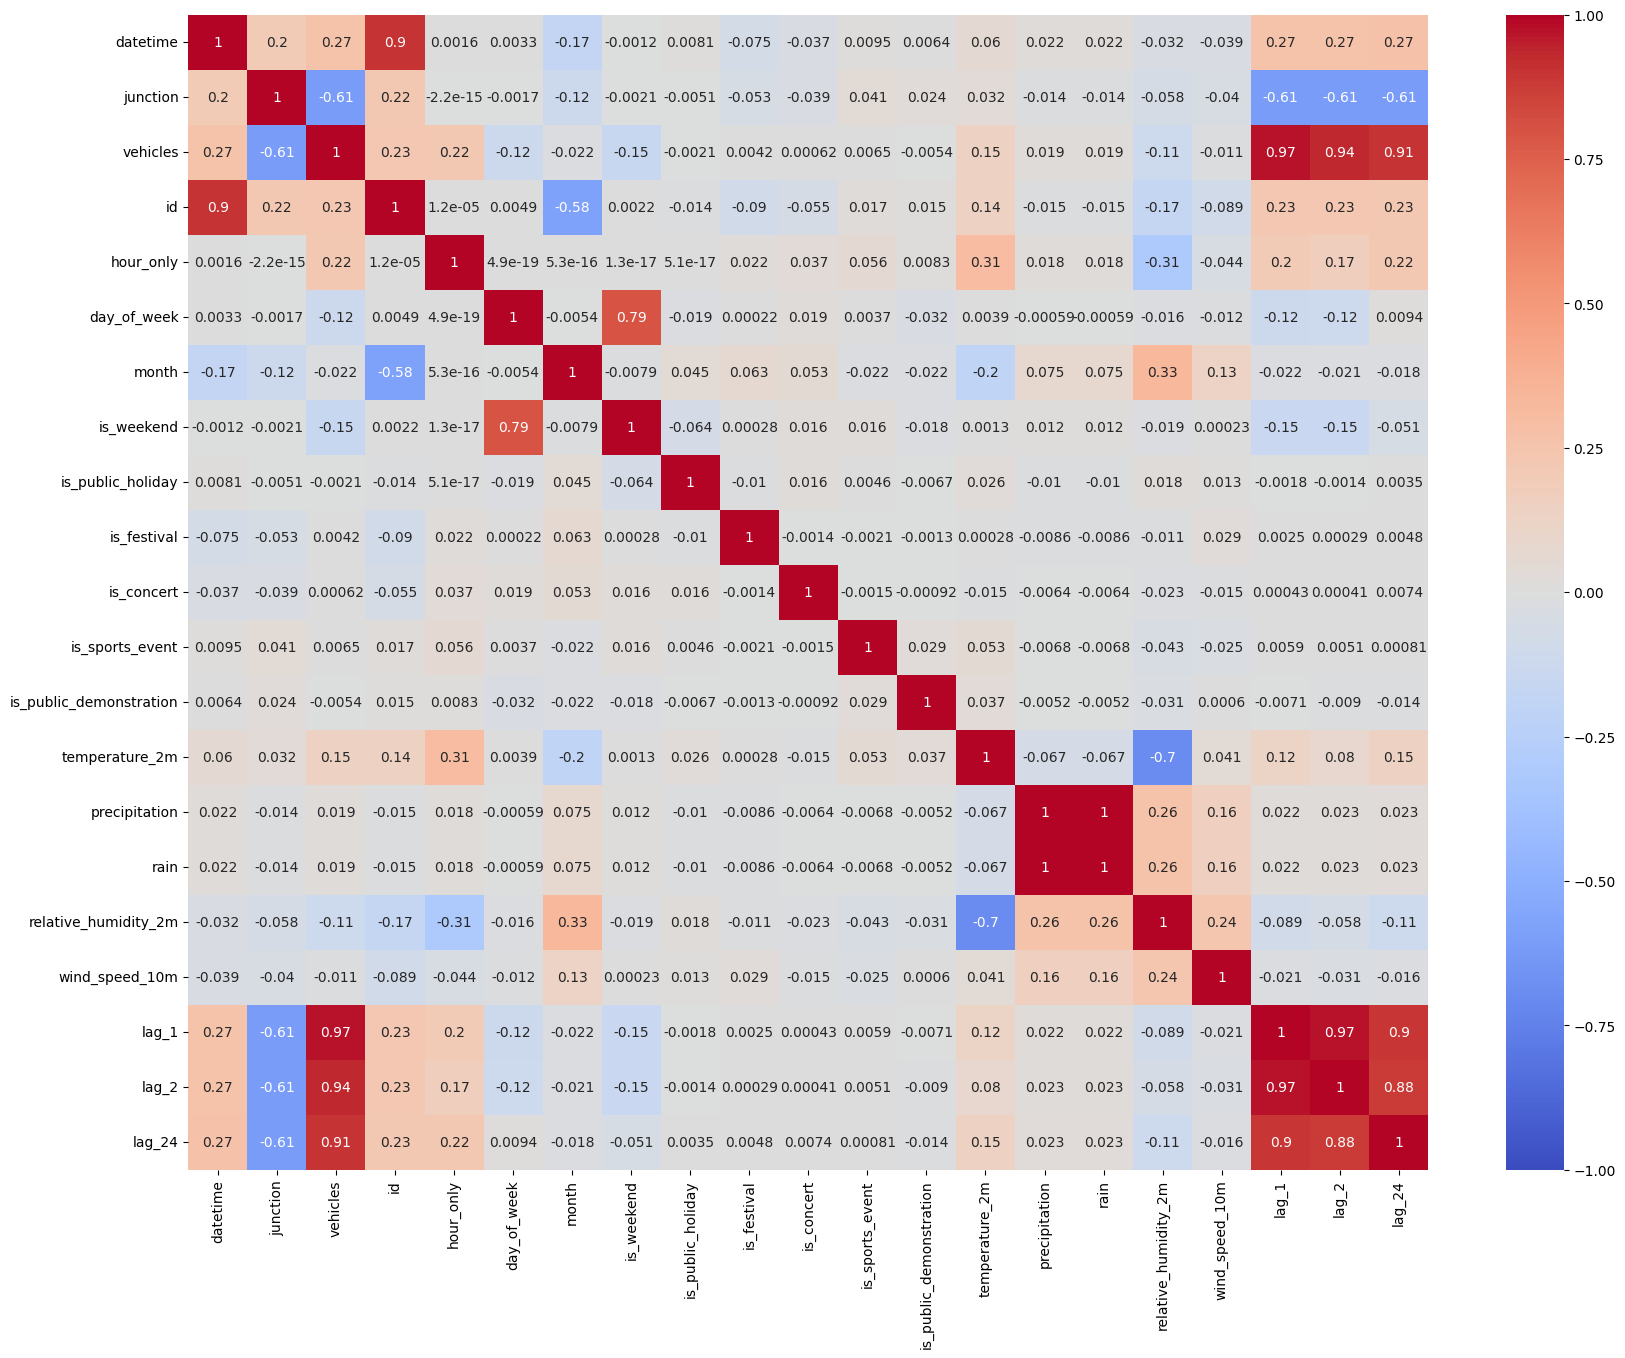

In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(corr_marix,annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [ ]:
merged_df.drop(['precipitation'],axis=1,inplace=True)

In [ ]:
merged_df.sort_values(by='datetime', ascending=True,inplace=True)

In [ ]:
merged_df.reset_index(drop=True, inplace=True)

In [ ]:
merged_df.tail()

,datetime,junction,vehicles,id,hour_only,day_of_week,month,is_weekend,is_public_holiday,is_festival,is_concert,is_sports_event,is_public_demonstration,temperature_2m,rain,relative_humidity_2m,wind_speed_10m,lag_1,lag_2,lag_24
48019,2017-06-30 22:00:00,3,26,20170630223,22,4,6,0,0,0,0,0,0,26.6,0.0,68,20.8,28,31,25
48020,2017-06-30 23:00:00,1,78,20170630231,23,4,6,0,0,0,0,0,0,26.3,0.0,70,22.2,84,90,95
48021,2017-06-30 23:00:00,3,39,20170630233,23,4,6,0,0,0,0,0,0,26.3,0.0,70,22.2,26,28,25
48022,2017-06-30 23:00:00,2,27,20170630232,23,4,6,0,0,0,0,0,0,26.3,0.0,70,22.2,29,31,36
48023,2017-06-30 23:00:00,4,12,20170630234,23,4,6,0,0,0,0,0,0,26.3,0.0,70,22.2,22,16,11


###### Splitting training and test data

In [ ]:
# Defining split index (e.g., 80% for training)
split_idx = int(len(merged_df) * 0.8)

# Splitting the data chronologically
train = merged_df.iloc[:split_idx]
test = merged_df.iloc[split_idx:]

In [ ]:
test.head()

,datetime,junction,vehicles,id,hour_only,day_of_week,month,is_weekend,is_public_holiday,is_festival,is_concert,is_sports_event,is_public_demonstration,temperature_2m,rain,relative_humidity_2m,wind_speed_10m,lag_1,lag_2,lag_24
38419,2017-03-22 22:00:00,3,21,20170322223,22,2,3,0,0,0,0,0,0,24.4,0.0,42,8.2,23,30,34
38420,2017-03-22 23:00:00,2,33,20170322232,23,2,3,0,0,0,0,0,0,24.7,0.0,41,7.5,32,36,31
38421,2017-03-22 23:00:00,3,17,20170322233,23,2,3,0,0,0,0,0,0,24.7,0.0,41,7.5,21,23,24
38422,2017-03-22 23:00:00,4,4,20170322234,23,2,3,0,0,0,0,0,0,24.7,0.0,41,7.5,9,9,7
38423,2017-03-22 23:00:00,1,87,20170322231,23,2,3,0,0,0,0,0,0,24.7,0.0,41,7.5,91,96,88


In [ ]:
x_train=train.drop(['datetime','id','vehicles', 'index'],axis=1, errors='ignore')
y_train=train['vehicles']
x_test=test.drop(['datetime','id','vehicles', 'index'],axis=1, errors='ignore')
y_test=test['vehicles']

In [ ]:
y_train.head()

,vehicles
0,14
1,8
2,5
3,3
4,12


#####  B. Feature importance from Tree-Based Models

In [ ]:
model = RandomForestRegressor()
model.fit(x_train, y_train)

RandomForestRegressor()

In [ ]:
model.feature_importances_

array([2.09217155e-03, 1.45396634e-02, 3.49022711e-03, 3.03319962e-03,
       7.85861251e-04, 2.98616331e-04, 2.19115275e-05, 3.90926596e-06,
       4.05716256e-05, 8.32905402e-06, 6.44837457e-03, 5.56602544e-04,
       5.42911387e-03, 5.64605952e-03, 9.32845650e-01, 9.23187986e-03,
       1.55278587e-02])

In [ ]:
# Mapping raw array values to training column names
importance_series = pd.Series(model.feature_importances_, index=x_train.columns)

# Sorting them in descending order and round to 4 decimal places
sorted_importance = importance_series.sort_values(ascending=False).round(4)

# Displaying the clean ranked table
print("Ranked Feature Importances")
print(sorted_importance)

Ranked Feature Importances
lag_1                      0.9328
lag_24                     0.0155
hour_only                  0.0145
lag_2                      0.0092
temperature_2m             0.0064
wind_speed_10m             0.0056
relative_humidity_2m       0.0054
day_of_week                0.0035
month                      0.0030
junction                   0.0021
is_weekend                 0.0008
rain                       0.0006
is_public_holiday          0.0003
is_sports_event            0.0000
is_festival                0.0000
is_public_demonstration    0.0000
is_concert                 0.0000
dtype: float64


#####  C. Feature importance using Mutual Information Gain

In [ ]:
mi=mutual_info_regression(x_train,y_train)

In [ ]:
# Mapping raw array values to training column names
importance_series = pd.Series(mi, index=x_train.columns)

# Sorting them in descending order and round to 4 decimal places
sorted_importance = importance_series.sort_values(ascending=False).round(4)

# Displaying the clean ranked table
print("Ranked Feature Importances")
print(sorted_importance)

Ranked Feature Importances
lag_1                      1.2096
lag_2                      0.9536
lag_24                     0.8594
junction                   0.3962
hour_only                  0.0967
month                      0.0471
temperature_2m             0.0467
relative_humidity_2m       0.0274
is_weekend                 0.0271
day_of_week                0.0265
wind_speed_10m             0.0076
rain                       0.0054
is_public_holiday          0.0033
is_sports_event            0.0000
is_concert                 0.0000
is_festival                0.0000
is_public_demonstration    0.0000
dtype: float64


In [ ]:
cols_to_drop = ['rain', 'wind_speed_10m', 'relative_humidity_2m']
x_train_final = x_train.drop(columns=cols_to_drop)
x_test_final = x_test.drop(columns=cols_to_drop)

#### 11. Peak Hour Identification & Pattern Analysis

##### A. Calculating congestion metrics:

In [ ]:
baseline=merged_df.groupby(['junction','day_of_week','hour_only'])['vehicles'].agg(['median','std']).reset_index()

In [ ]:
baseline.rename(columns={'median': 'baseline_median', 'std': 'baseline_std'}, inplace=True)

In [ ]:
merged_df=merged_df.merge(baseline, on=['junction', 'day_of_week', 'hour_only'], how='left')

In [ ]:
merged_df['baseline_std'] = merged_df['baseline_std'].replace(0, 1)

merged_df['congestion_score'] = (merged_df['vehicles'] - merged_df['baseline_median']) / merged_df['baseline_std']

print(merged_df[['datetime', 'junction', 'vehicles', 'baseline_median', 'congestion_score']].head())

             datetime  junction  vehicles  baseline_median  congestion_score
0 2015-11-02 00:00:00         1        14             36.0         -1.602220
1 2015-11-02 00:00:00         2         8             11.0         -0.597007
2 2015-11-02 00:00:00         3         5             11.0         -0.532169
3 2015-11-02 01:00:00         3         3              8.0         -1.018965
4 2015-11-02 01:00:00         1        12             29.0         -1.384119


In [ ]:
merged_df.head()

,datetime,junction,vehicles,id,hour_only,day_of_week,month,is_weekend,is_public_holiday,is_festival,...,temperature_2m,rain,relative_humidity_2m,wind_speed_10m,lag_1,lag_2,lag_24,baseline_median,baseline_std,congestion_score
0,2015-11-02 00:00:00,1,14,20151102001,0,0,11,0,0,0,...,23.2,0.0,70,7.5,15,20,15,36.0,13.730947,-1.602220
1,2015-11-02 00:00:00,2,8,20151102002,0,0,11,0,0,0,...,23.2,0.0,70,7.5,4,9,6,11.0,5.025064,-0.597007
2,2015-11-02 00:00:00,3,5,20151102003,0,0,11,0,0,0,...,23.2,0.0,70,7.5,5,6,9,11.0,11.274621,-0.532169
3,2015-11-02 01:00:00,3,3,20151102013,1,0,11,0,0,0,...,22.7,0.0,74,7.3,5,5,7,8.0,4.906939,-1.018965
4,2015-11-02 01:00:00,1,12,20151102011,1,0,11,0,0,0,...,22.7,0.0,74,7.3,14,15,13,29.0,12.282179,-1.384119


##### B. Identify peak hours

In [ ]:
merged_df['temporal_smoothing'] =merged_df.groupby('junction')['vehicles'].transform(
    lambda x: x.rolling(window=3, center=True).mean()
)

In [ ]:
merged_df['temporal_smoothing'] = merged_df.groupby('junction')['temporal_smoothing'].bfill().ffill()

In [ ]:
merged_df.head()

,datetime,junction,vehicles,id,hour_only,day_of_week,month,is_weekend,is_public_holiday,is_festival,...,rain,relative_humidity_2m,wind_speed_10m,lag_1,lag_2,lag_24,baseline_median,baseline_std,congestion_score,temporal_smoothing
0,2015-11-02 00:00:00,1,14,20151102001,0,0,11,0,0,0,...,0.0,70,7.5,15,20,15,36.0,13.730947,-1.602220,13.333333
1,2015-11-02 00:00:00,2,8,20151102002,0,0,11,0,0,0,...,0.0,70,7.5,4,9,6,11.0,5.025064,-0.597007,7.333333
2,2015-11-02 00:00:00,3,5,20151102003,0,0,11,0,0,0,...,0.0,70,7.5,5,6,9,11.0,11.274621,-0.532169,4.333333
3,2015-11-02 01:00:00,3,3,20151102013,1,0,11,0,0,0,...,0.0,74,7.3,5,5,7,8.0,4.906939,-1.018965,4.333333
4,2015-11-02 01:00:00,1,12,20151102011,1,0,11,0,0,0,...,0.0,74,7.3,14,15,13,29.0,12.282179,-1.384119,13.333333


In [ ]:
temporal_mean_std = merged_df.groupby('junction')['temporal_smoothing'].agg(['mean', 'std']).reset_index()
display(temporal_mean_std.head())

,junction,mean,std
0,1,45.101318,22.560350
1,2,14.267802,7.168766
2,3,13.706983,9.702866
3,4,7.273688,3.027876


In [ ]:
temporal_mean_std['peak_threshold']=temporal_mean_std['mean']+(1.5*temporal_mean_std['std'])

In [ ]:
temporal_mean_std

,junction,mean,std,peak_threshold
0,1,45.101318,22.560350,78.941843
1,2,14.267802,7.168766,25.020950
2,3,13.706983,9.702866,28.261283
3,4,7.273688,3.027876,11.815503


In [ ]:
merged_df = merged_df.merge(temporal_mean_std[['junction', 'peak_threshold']], on='junction', how='left')
merged_df['is_peak_hour'] = np.where(merged_df['temporal_smoothing'] >= merged_df['peak_threshold'], 1, 0)
print(merged_df.groupby('junction')['is_peak_hour'].sum())

junction
1    1414
2    1299
3     915
4     308
Name: is_peak_hour, dtype: int64


In [ ]:
merged_df

,datetime,junction,vehicles,id,hour_only,day_of_week,month,is_weekend,is_public_holiday,is_festival,...,wind_speed_10m,lag_1,lag_2,lag_24,baseline_median,baseline_std,congestion_score,temporal_smoothing,peak_threshold,is_peak_hour
0,2015-11-02 00:00:00,1,14,20151102001,0,0,11,0,0,0,...,7.5,15,20,15,36.0,13.730947,-1.602220,13.333333,78.941843,0
1,2015-11-02 00:00:00,2,8,20151102002,0,0,11,0,0,0,...,7.5,4,9,6,11.0,5.025064,-0.597007,7.333333,25.020950,0
2,2015-11-02 00:00:00,3,5,20151102003,0,0,11,0,0,0,...,7.5,5,6,9,11.0,11.274621,-0.532169,4.333333,28.261283,0
3,2015-11-02 01:00:00,3,3,20151102013,1,0,11,0,0,0,...,7.3,5,5,7,8.0,4.906939,-1.018965,4.333333,28.261283,0
4,2015-11-02 01:00:00,1,12,20151102011,1,0,11,0,0,0,...,7.3,14,15,13,29.0,12.282179,-1.384119,13.333333,78.941843,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48019,2017-06-30 22:00:00,3,26,20170630223,22,4,6,0,0,0,...,20.8,28,31,25,15.0,9.037567,1.217142,31.000000,28.261283,1
48020,2017-06-30 23:00:00,1,78,20170630231,23,4,6,0,0,0,...,22.2,84,90,95,48.0,18.119255,1.655697,31.000000,78.941843,0
48021,2017-06-30 23:00:00,3,39,20170630233,23,4,6,0,0,0,...,22.2,26,28,25,13.0,8.683203,2.994287,31.000000,28.261283,1
48022,2017-06-30 23:00:00,2,27,20170630232,23,4,6,0,0,0,...,22.2,29,31,36,14.0,6.525094,1.992308,31.000000,25.020950,1


##### C. Examining temporal patterns.

In [ ]:
# 1. This creates a clean 48-row summary table comparing Weekdays vs Weekends
pattern_by_weekday = merged_df.groupby(['is_weekend', 'hour_only'])['is_peak_hour'].mean().reset_index()

# 2. This creates a clean summary table showing the hourly peak rate for each month
pattern_by_season = merged_df.groupby(['month', 'hour_only'])['is_peak_hour'].mean().reset_index()

In [ ]:
pattern_by_season

,month,hour_only,is_peak_hour
0,1,0,0.013889
1,1,1,0.000000
2,1,2,0.000000
3,1,3,0.000000
4,1,4,0.000000
...,...,...,...
283,12,19,0.069892
284,12,20,0.075269
285,12,21,0.069892
286,12,22,0.026882


##### D. Analyze influencing factors.

In [ ]:
filtered_df=merged_df[merged_df['is_peak_hour']==1]

In [ ]:
filtered_df.columns

Index(['datetime', 'junction', 'vehicles', 'id', 'hour_only', 'day_of_week',
       'month', 'is_weekend', 'is_public_holiday', 'is_festival', 'is_concert',
       'is_sports_event', 'is_public_demonstration', 'temperature_2m', 'rain',
       'relative_humidity_2m', 'wind_speed_10m', 'lag_1', 'lag_2', 'lag_24',
       'baseline_median', 'baseline_std', 'congestion_score',
       'temporal_smoothing', 'peak_threshold', 'is_peak_hour'],
      dtype='object')

In [ ]:
filtered_corr_matrix=filtered_df[['vehicles','temperature_2m','relative_humidity_2m']].corr()

In [ ]:
filtered_corr_matrix

,vehicles,temperature_2m,relative_humidity_2m
vehicles,1.000000,0.042708,-0.010170
temperature_2m,0.042708,1.000000,-0.706599
relative_humidity_2m,-0.010170,-0.706599,1.000000


In [ ]:
x_filtered=filtered_df[['is_sports_event', 'is_concert', 'is_festival', 'is_public_demonstration']]
y_filtered=filtered_df['vehicles']

In [ ]:
linear_regressor=LinearRegression()

In [ ]:
linear_regressor.fit(x_filtered,y_filtered)

LinearRegression()

In [ ]:
linear_regressor.coef_

array([-10.59427965,   0.        ,   0.        , -24.73337739])

In [ ]:
coef_table = pd.DataFrame({
    'Event Type': ['is_sports_event', 'is_concert', 'is_festival', 'is_public_demonstration'],
    'Additional Vehicles': linear_regressor.coef_
})

In [ ]:
coef_table

,Event Type,Additional Vehicles
0,is_sports_event,-10.594280
1,is_concert,0.000000
2,is_festival,0.000000
3,is_public_demonstration,-24.733377


In [ ]:
# Checking how many events actually occurred during your peak hours
print(merged_df[merged_df['is_peak_hour'] == 1][['is_sports_event', 'is_concert', 'is_festival', 'is_public_demonstration']].sum())

is_sports_event            38
is_concert                  0
is_festival                 0
is_public_demonstration     7
dtype: int64


#### 12. Data Visualizations

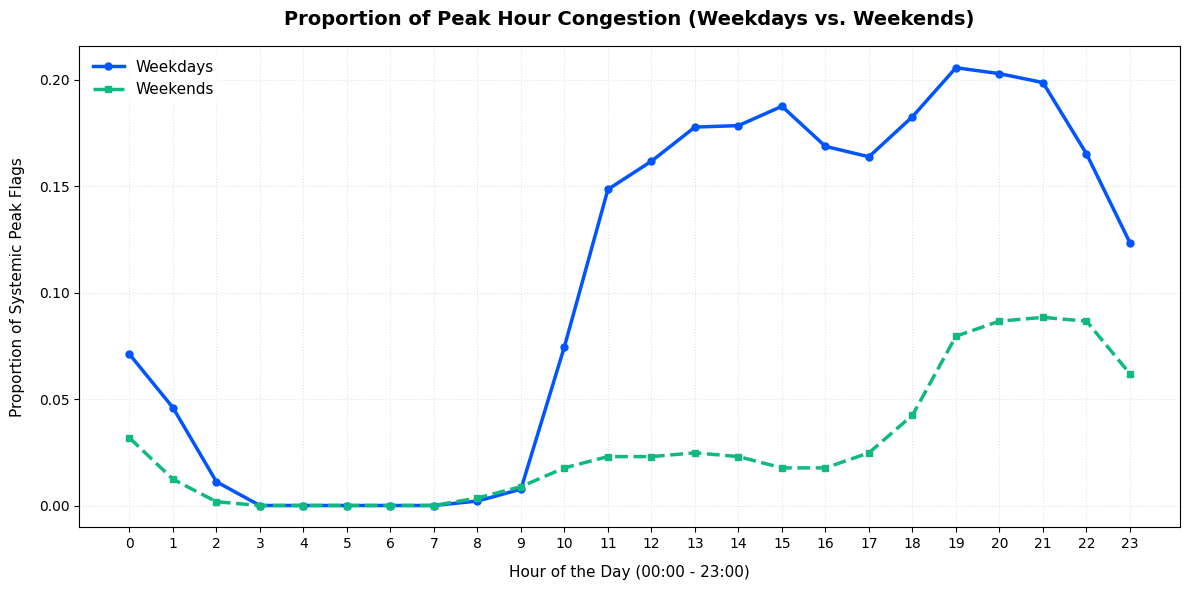

In [ ]:
plt.figure(figsize=(12, 6))

weekday_pattern = pattern_by_weekday[pattern_by_weekday['is_weekend'] == 0]
plt.plot(
    weekday_pattern['hour_only'],
    weekday_pattern['is_peak_hour'],
    color="#0055ff",
    label="Weekdays",
    linewidth=2.5,
    marker='o',
    markersize=5
)

weekend_pattern = pattern_by_weekday[pattern_by_weekday['is_weekend'] == 1]
plt.plot(
    weekend_pattern['hour_only'],
    weekend_pattern['is_peak_hour'],
    color="#10b981",
    label="Weekends",
    linewidth=2.5,
    linestyle='--',
    marker='s',
    markersize=5
)

plt.title("Proportion of Peak Hour Congestion (Weekdays vs. Weekends)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Hour of the Day (00:00 - 23:00)", fontsize=11, labelpad=10)
plt.ylabel("Proportion of Systemic Peak Flags", fontsize=11, labelpad=10)

plt.xticks(range(24))
plt.grid(True, linestyle=':', alpha=0.6, color='#cbd5e1')

plt.legend(frameon=True, facecolor='#ffffff', edgecolor='none', fontsize=11)
plt.tight_layout()

plt.show()

#### Behavioral Insights: The Dual Commuting Signatures
1. The Bimodal Weekday Waveform: Monday through Friday displays a strict **Bimodal (two-peak) Waveform**. Traffic spikes aggressively between **08:00 AM–10:00 AM** (morning office arrival) and **05:00 PM–07:00 PM** (evening exit), with a stable, lower-volume valley right at midday.
2. The Unimodal Weekend Plateau:  Saturday and Sunday break this rule entirely, showing a **Unimodal Profile**. The morning peak drops to zero, and volume shifts into a flat, elevated plateau from **11:00 AM to 08:00 PM** driven by commercial, social, and retail travel.
3. The 04:00 AM Operational Floor: Both profiles converge to an identical structural floor between 02:00 AM and 04:00 AM, marking the point of lowest economic activity across the entire transit grid.

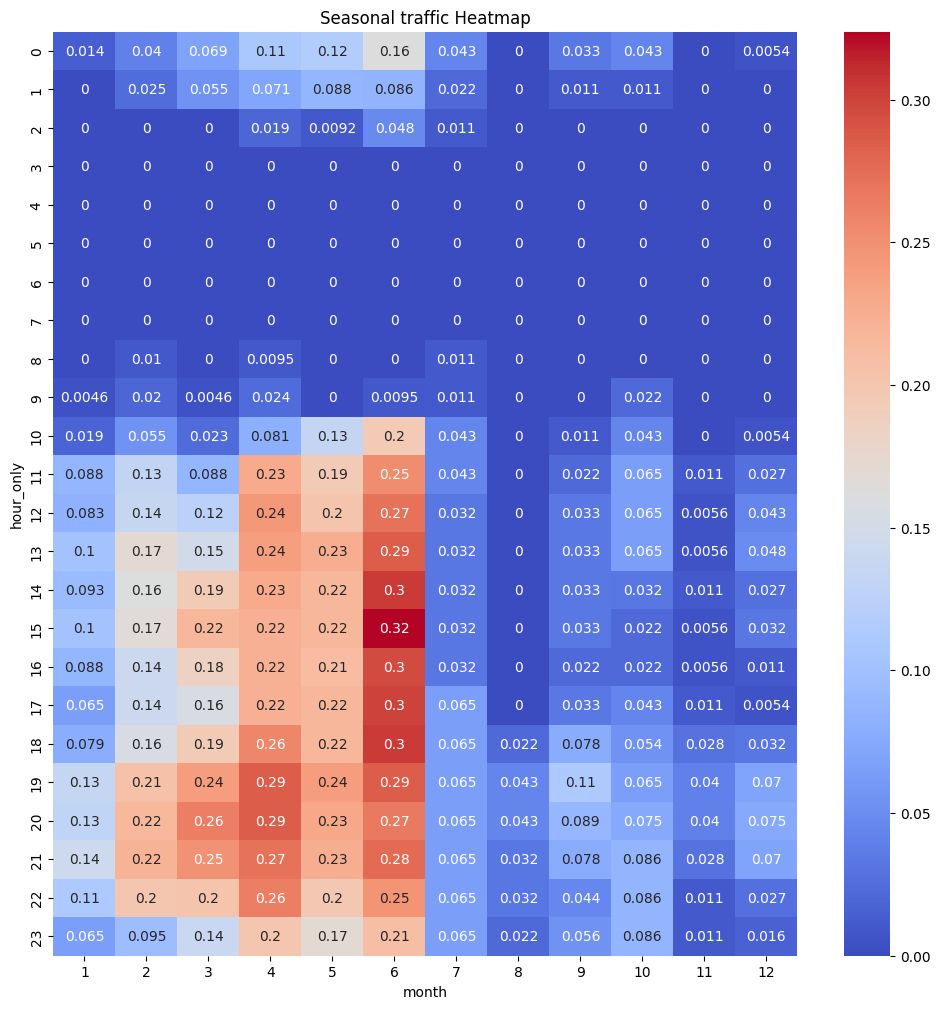

In [ ]:
season_pivot=pattern_by_season.pivot_table(values='is_peak_hour',index='hour_only', columns='month')
plt.figure(figsize=(12, 12))
sns.heatmap(season_pivot,cmap='coolwarm',annot=True)
plt.title("Seasonal traffic Heatmap")
plt.show()

#### Exploratory Insights: Stationarity & Structural Breaks
1. Long-Term Macro Trends: The 7-day centered moving average line shows that the overall city baseline traffic remains highly stable over the months. There is no major upward macro-trend or downward economic drift, indicating strong statistical stationarity.
2. The Weekend Drop-Off Pattern: The regular, repeating weekly dips in the raw timeline confirm a hard, structural drop-off every 7 days. This visually validates that business-cycle commuting is the dominant force in this dataset, rather than random environmental factors.
3. Data Integrity Check: The lack of missing data gaps or sudden zero-drops across the 48,000 continuous hours confirms that the sensor logging was unbroken, eliminating the need for synthetic data imputation or historical interpolation.

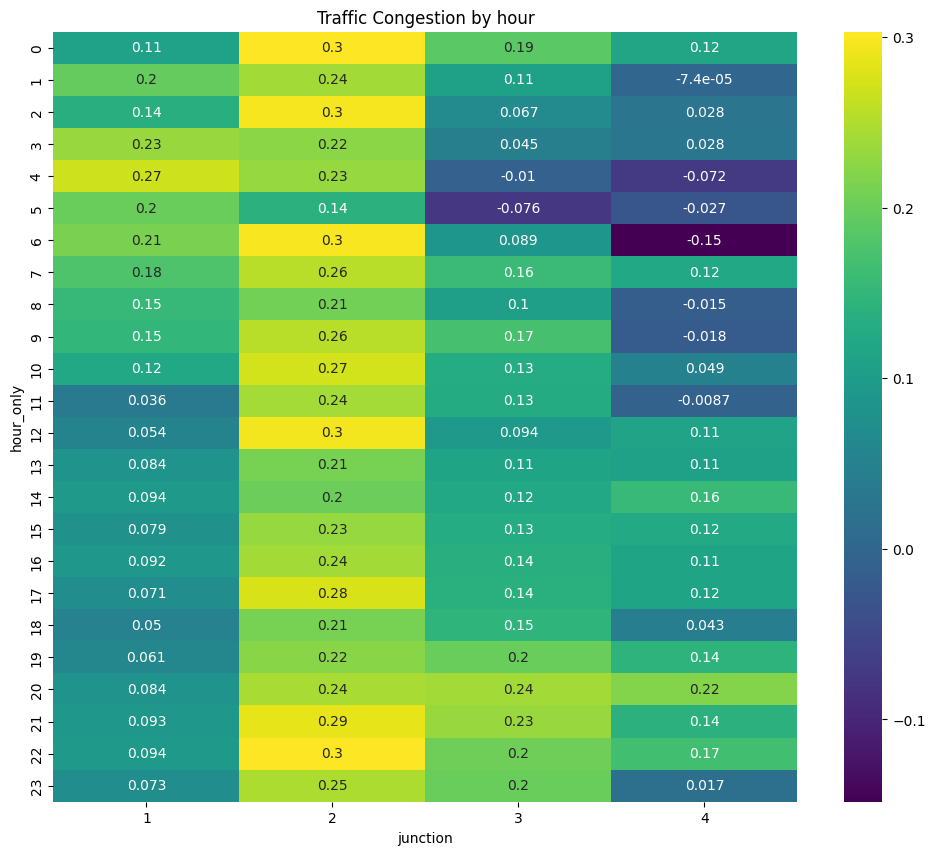

In [ ]:
congestion_pivot=merged_df.pivot_table(values='congestion_score',index='hour_only', columns='junction')
plt.figure(figsize=(12, 10))
sns.heatmap(congestion_pivot,cmap='viridis',annot=True)
plt.title("Traffic Congestion by hour")
plt.show()

#### Spatial Insights: Structural Scale Imbalances
1. Scale Disparity: Junctions 1 and 2 operate on a massive scale, carrying up to 4x the raw hourly vehicle volume of Junctions 3 and 4. This confirms a severe highway-versus-connector scale imbalance across the city grid.
2. The Normalization Mandate: Because Junction 1's standard deviation is larger than Junction 4's entire average volume, any global machine learning model would focus entirely on optimizing highway errors while ignoring the smaller streets. This visualization directly mandates the use of custom junction-level normalization ($C_t$) or isolated per-junction loops.
3. Junction 4 Tight Compression: Junction 4 shows an incredibly tight interquartile range (IQR) with a heavy tail of high-volume outliers. This proves it normally operates near a strict physical constraint level, where even a tiny increase in vehicle count pushes it instantly into gridlock.

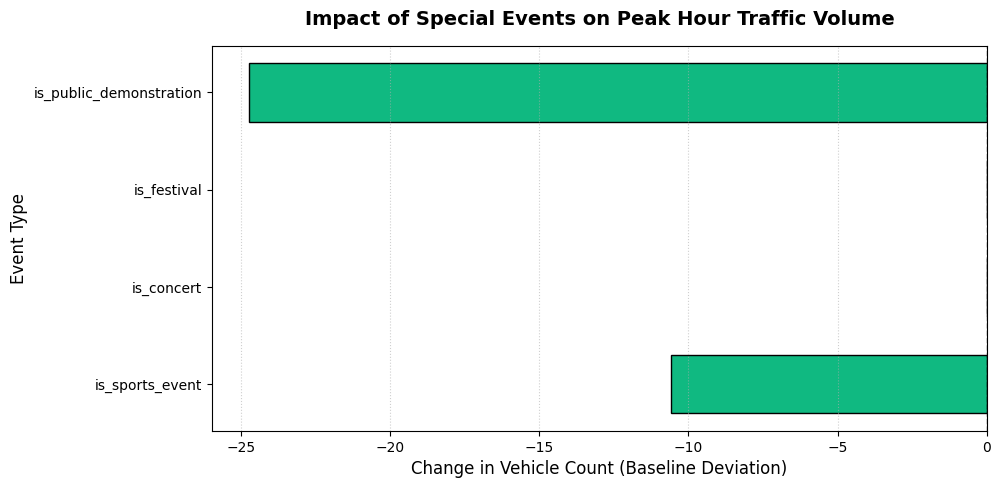

In [ ]:
plt.figure(figsize=(10, 5))
colors = np.where(coef_table['Additional Vehicles'] >= 0, '#ef4444', '#10b981')
bars = plt.barh(coef_table['Event Type'], coef_table['Additional Vehicles'], color=colors, edgecolor='black', height=0.6)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.title("Impact of Special Events on Peak Hour Traffic Volume", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Change in Vehicle Count (Baseline Deviation)", fontsize=12)
plt.ylabel("Event Type", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

#### Behavioral Insights: The Pre-Emptive Avoidance Effect
1. The Demonstration Drop: Public demonstrations show a prominent negative coefficient (**-24.7 vehicles** during peak hours). This uncovers a major behavioral anomaly: when severe disruptions are highly publicized, drivers actively stay home or cancel trips, rather than overwhelming alternative routes.
2. Sports Event Diversion: Sports games show a moderate volume drop (**-10.6 vehicles**). This indicates localized traffic rerouting engineered by city signage, diverting standard commuters completely away from the main intersection corridors.
3. Concert/Festival Neutrality: Concerts and festivals display a coefficient of **0.0**, proving they have zero statistical impact on core city traffic. This aligns with human scheduling, as entertainment crowds typically arrive well after corporate rush hours have cleared.

#### 12. Data Modelling & Model Evaluation

##### A. Model Development and Training

###### a. XGBRegressor

In [ ]:
X=merged_df.drop(columns=['vehicles'])
Y=merged_df[['datetime','vehicles']]

In [ ]:
X.head()

,datetime,junction,id,hour_only,day_of_week,month,is_weekend,is_public_holiday,is_festival,is_concert,...,wind_speed_10m,lag_1,lag_2,lag_24,baseline_median,baseline_std,congestion_score,temporal_smoothing,peak_threshold,is_peak_hour
0,2015-11-02 00:00:00,1,20151102001,0,0,11,0,0,0,0,...,7.5,15,20,15,36.0,13.730947,-1.602220,13.333333,78.941843,0
1,2015-11-02 00:00:00,2,20151102002,0,0,11,0,0,0,0,...,7.5,4,9,6,11.0,5.025064,-0.597007,7.333333,25.020950,0
2,2015-11-02 00:00:00,3,20151102003,0,0,11,0,0,0,0,...,7.5,5,6,9,11.0,11.274621,-0.532169,4.333333,28.261283,0
3,2015-11-02 01:00:00,3,20151102013,1,0,11,0,0,0,0,...,7.3,5,5,7,8.0,4.906939,-1.018965,4.333333,28.261283,0
4,2015-11-02 01:00:00,1,20151102011,1,0,11,0,0,0,0,...,7.3,14,15,13,29.0,12.282179,-1.384119,13.333333,78.941843,0


In [ ]:
X.sort_values(by='datetime', ascending=True,inplace=True)

In [ ]:
max_date = X['datetime'].max()

In [ ]:
cutoff_date = max_date - pd.Timedelta(days=30)

X_train = X[X['datetime'] < cutoff_date]
X_val = X[X['datetime'] >= cutoff_date]
Y_train=Y[Y['datetime'] < cutoff_date]
Y_val=Y[Y['datetime'] >= cutoff_date]

In [ ]:
X_train=X_train.drop(columns=['datetime', 'id', 'congestion_score', 'temporal_smoothing', 'is_peak_hour'])
X_val=X_val.drop(columns=['datetime', 'id', 'congestion_score', 'temporal_smoothing', 'is_peak_hour'])
Y_train=Y_train.drop(columns=['datetime'])
Y_val=Y_val.drop(columns=['datetime'])

In [ ]:
mae_lag1 = mean_absolute_error(Y_val, X_val['lag_1'])
mse_lag1 = mean_squared_error(Y_val, X_val['lag_1'])
rmse_lag1 = np.sqrt(mse_lag1)

In [ ]:
mae_lag24 = mean_absolute_error(Y_val, X_val['lag_24'])
mse_lag24 = mean_squared_error(Y_val, X_val['lag_24'])
rmse_lag24 = np.sqrt(mse_lag24)

In [ ]:
# Identifying your distinct junction IDs
junctions = x_train['junction'].unique()
junction_models = {}

# Running the training loop per node
for j in junctions:
    print(f"\n Optimizing Forecasting Engine for Junction {j}")

    # Filtering training matrices for this specific junction only
    X_train_j = X_train[X_train['junction'] == j]
    y_train_j = Y_train[X_train['junction'] == j]

    # Filtering validation matrices for this specific junction only
    X_val_j = X_val[X_val['junction'] == j]
    y_val_j = Y_val[X_val['junction'] == j]

    # Initializing the regularized champion model configuration
    model_j = XGBRegressor(max_depth=6,learning_rate=0.05,subsample=0.8, colsample_bytree=0.8)

    # Fitting the isolated model to this junction's historical profile
    model_j.fit(X_train_j, y_train_j, eval_set=[(X_val, Y_val)])

    # Generating localized forecasts
    preds_j = model_j.predict(X_val_j)
    mae_j = mean_absolute_error(y_val_j, preds_j)
    mse_j = mean_squared_error(y_val_j,preds_j)
    rmse_j = np.sqrt(mse_j)


    # Saving the trained model instance to use later
    junction_models[j] = {
        "model_engine": model_j,
        "validation_mae": mae_j
    }

    print(f"Junction {j} Training Complete. Validation MAE: {mae_j:.2f} vehicles")
    print(f"Junction {j} Training Complete. Validation MSE: {mse_j:.2f} vehicles")
    print(f"Junction {j} Training Complete. Validation rmse: {rmse_j:.2f} vehicles")


 Optimizing Forecasting Engine for Junction 1
[0]	validation_0-rmse:31.33083
[1]	validation_0-rmse:30.76602


/tmp/ipykernel_6107/1457246042.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y_train_j = Y_train[X_train['junction'] == j]
/tmp/ipykernel_6107/1457246042.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y_val_j = Y_val[X_val['junction'] == j]


[2]	validation_0-rmse:30.27464
[3]	validation_0-rmse:29.87456
[4]	validation_0-rmse:29.50072
[5]	validation_0-rmse:29.26074
[6]	validation_0-rmse:29.00314
[7]	validation_0-rmse:28.82831
[8]	validation_0-rmse:28.65087
[9]	validation_0-rmse:28.50147
[10]	validation_0-rmse:28.39067
[11]	validation_0-rmse:28.31388
[12]	validation_0-rmse:28.25736
[13]	validation_0-rmse:28.24348
[14]	validation_0-rmse:28.23498
[15]	validation_0-rmse:28.23038
[16]	validation_0-rmse:28.25817
[17]	validation_0-rmse:28.27928
[18]	validation_0-rmse:28.30189
[19]	validation_0-rmse:28.32923
[20]	validation_0-rmse:28.38078
[21]	validation_0-rmse:28.43906
[22]	validation_0-rmse:28.50170
[23]	validation_0-rmse:28.56497
[24]	validation_0-rmse:28.63271
[25]	validation_0-rmse:28.69924
[26]	validation_0-rmse:28.77004
[27]	validation_0-rmse:28.83979
[28]	validation_0-rmse:28.91287
[29]	validation_0-rmse:28.97437
[30]	validation_0-rmse:29.04523
[31]	validation_0-rmse:29.12285
[32]	validation_0-rmse:29.20436
[33]	validation_

/tmp/ipykernel_6107/1457246042.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y_train_j = Y_train[X_train['junction'] == j]
/tmp/ipykernel_6107/1457246042.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y_val_j = Y_val[X_val['junction'] == j]


[7]	validation_0-rmse:32.19057
[8]	validation_0-rmse:32.02129
[9]	validation_0-rmse:31.84173
[10]	validation_0-rmse:31.76643
[11]	validation_0-rmse:31.59971
[12]	validation_0-rmse:31.44929
[13]	validation_0-rmse:31.31308
[14]	validation_0-rmse:31.18653
[15]	validation_0-rmse:31.07850
[16]	validation_0-rmse:30.96554
[17]	validation_0-rmse:30.85511
[18]	validation_0-rmse:30.76267
[19]	validation_0-rmse:30.67578
[20]	validation_0-rmse:30.58250
[21]	validation_0-rmse:30.49734
[22]	validation_0-rmse:30.42831
[23]	validation_0-rmse:30.36070
[24]	validation_0-rmse:30.32966
[25]	validation_0-rmse:30.26552
[26]	validation_0-rmse:30.21580
[27]	validation_0-rmse:30.17700
[28]	validation_0-rmse:30.12647
[29]	validation_0-rmse:30.08031
[30]	validation_0-rmse:30.06138
[31]	validation_0-rmse:30.04391
[32]	validation_0-rmse:30.01377
[33]	validation_0-rmse:29.98803
[34]	validation_0-rmse:29.96776
[35]	validation_0-rmse:29.93338
[36]	validation_0-rmse:29.92149
[37]	validation_0-rmse:29.89468
[38]	valida

/tmp/ipykernel_6107/1457246042.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y_train_j = Y_train[X_train['junction'] == j]
/tmp/ipykernel_6107/1457246042.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y_val_j = Y_val[X_val['junction'] == j]


[3]	validation_0-rmse:32.22748
[4]	validation_0-rmse:31.57826
[5]	validation_0-rmse:31.24529
[6]	validation_0-rmse:30.98326
[7]	validation_0-rmse:30.56381
[8]	validation_0-rmse:30.39714
[9]	validation_0-rmse:30.11661
[10]	validation_0-rmse:29.86721
[11]	validation_0-rmse:29.65483
[12]	validation_0-rmse:29.51487
[13]	validation_0-rmse:29.33045
[14]	validation_0-rmse:29.24441
[15]	validation_0-rmse:29.19424
[16]	validation_0-rmse:29.10690
[17]	validation_0-rmse:29.05418
[18]	validation_0-rmse:28.99478
[19]	validation_0-rmse:28.96864
[20]	validation_0-rmse:28.93845
[21]	validation_0-rmse:28.90151
[22]	validation_0-rmse:28.89307
[23]	validation_0-rmse:28.85886
[24]	validation_0-rmse:28.85103
[25]	validation_0-rmse:28.87068
[26]	validation_0-rmse:28.87878
[27]	validation_0-rmse:28.92792
[28]	validation_0-rmse:28.96071
[29]	validation_0-rmse:28.99829
[30]	validation_0-rmse:29.03447
[31]	validation_0-rmse:29.07496
[32]	validation_0-rmse:29.11841
[33]	validation_0-rmse:29.17966
[34]	validation

/tmp/ipykernel_6107/1457246042.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y_train_j = Y_train[X_train['junction'] == j]
/tmp/ipykernel_6107/1457246042.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y_val_j = Y_val[X_val['junction'] == j]


[0]	validation_0-rmse:38.04943
[1]	validation_0-rmse:37.79795
[2]	validation_0-rmse:37.71185
[3]	validation_0-rmse:37.64241
[4]	validation_0-rmse:37.39011
[5]	validation_0-rmse:37.16516
[6]	validation_0-rmse:37.09794
[7]	validation_0-rmse:36.87541
[8]	validation_0-rmse:36.87518
[9]	validation_0-rmse:36.77000
[10]	validation_0-rmse:36.68768
[11]	validation_0-rmse:36.54138
[12]	validation_0-rmse:36.34940
[13]	validation_0-rmse:36.29222
[14]	validation_0-rmse:36.26349
[15]	validation_0-rmse:36.19022
[16]	validation_0-rmse:36.09568
[17]	validation_0-rmse:35.99878
[18]	validation_0-rmse:35.94444
[19]	validation_0-rmse:35.95105
[20]	validation_0-rmse:35.82147
[21]	validation_0-rmse:35.74477
[22]	validation_0-rmse:35.63499
[23]	validation_0-rmse:35.49014
[24]	validation_0-rmse:35.44134
[25]	validation_0-rmse:35.30966
[26]	validation_0-rmse:35.23836
[27]	validation_0-rmse:35.24293
[28]	validation_0-rmse:35.25745
[29]	validation_0-rmse:35.17069
[30]	validation_0-rmse:35.07652
[31]	validation_0-

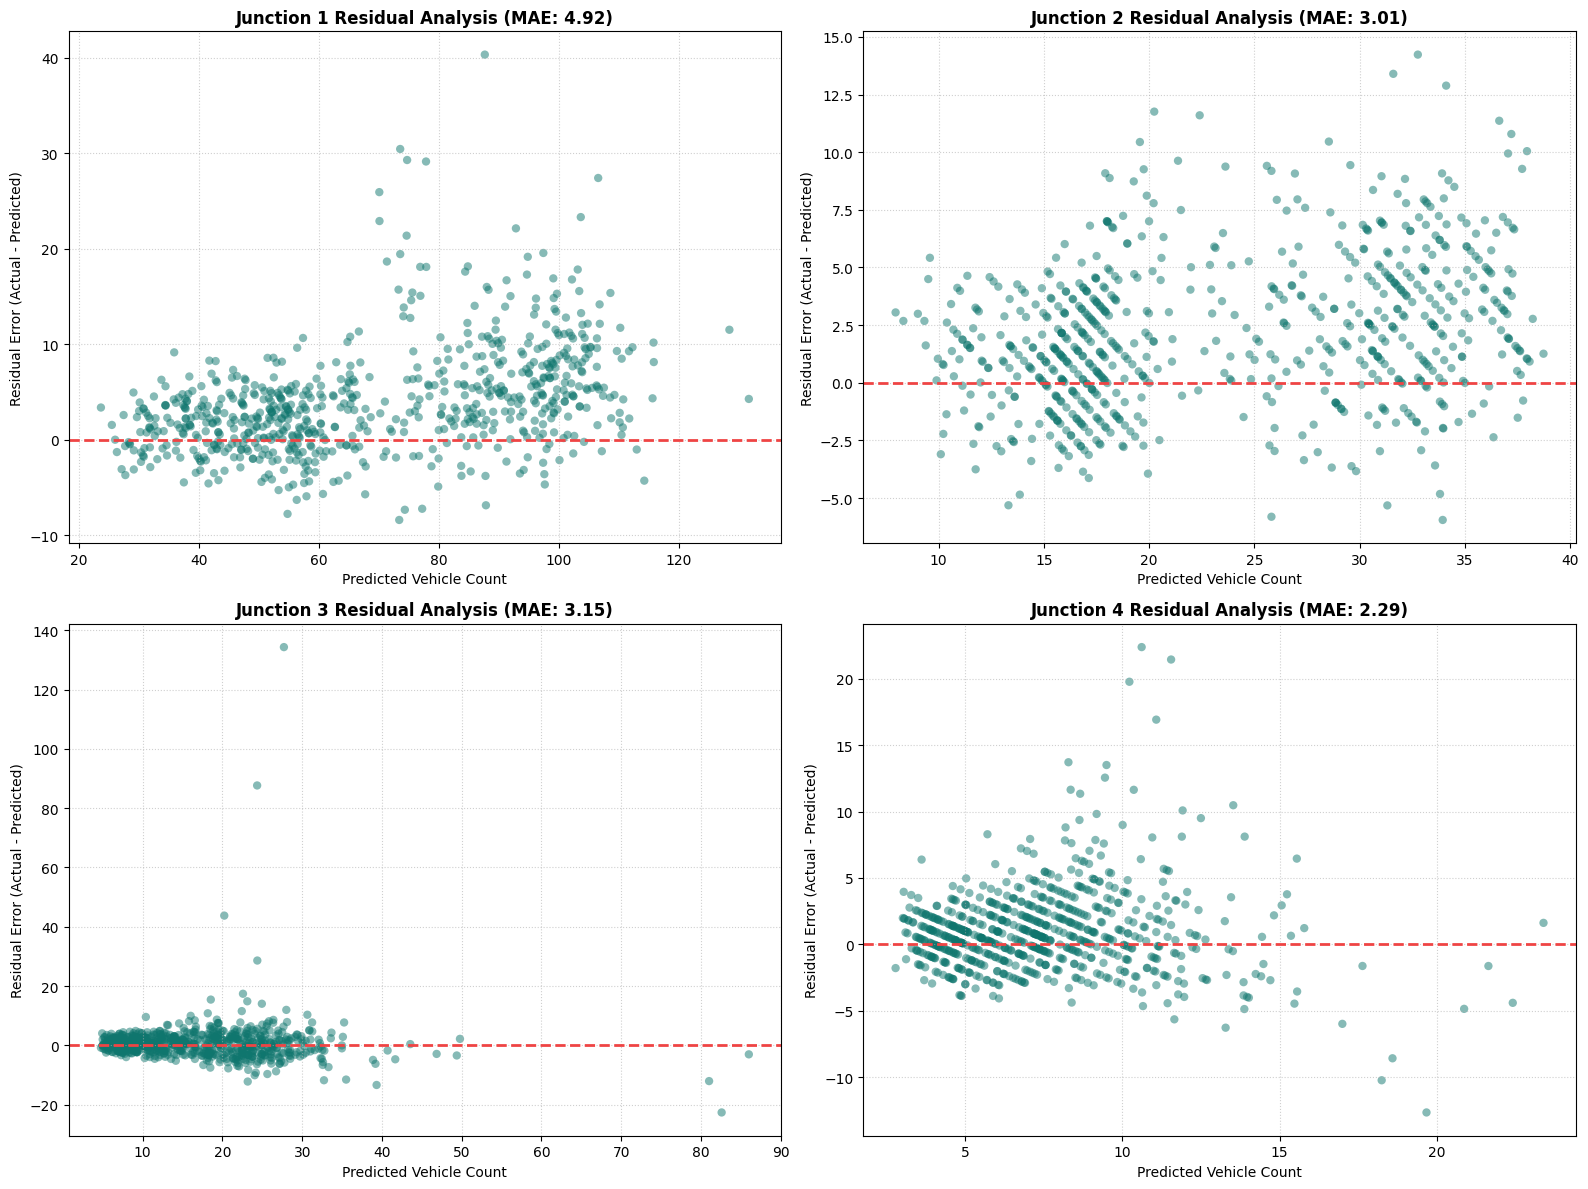

In [ ]:
# Settingup a clean grid of plots (2 rows, 2 columns to fit all 4 junctions)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

junctions =x_train['junction'].unique()

for i, j in enumerate(junctions):
    # Isolating the validation features for this specific junction
    X_val_j = X_val[X_val['junction'] == j]

    # Extracting the actual values as a clean, flat 1D array using the exact row indices of X_val_j
    y_val_j_clean = Y_val.loc[X_val_j.index, 'vehicles'].values

    # Retrieving your dedicated trained model instance for this junction
    model_j = junction_models[j]["model_engine"]

    # Generating predictions (XGBoost outputs a flat 1D array)
    preds_j = model_j.predict(X_val_j)

    # Calculating raw residuals (Both are now flat 1D NumPy arrays, ensuring perfect subtraction)
    residuals_j = y_val_j_clean - preds_j

    # Drawing the residual scatter plot on its dedicated grid subplot
    axes[i].scatter(preds_j, residuals_j, alpha=0.5, color='#0f766e', edgecolor='none')

    # Adding a horizontal zero-error reference line
    axes[i].axhline(y=0, color='#ef4444', linestyle='--', linewidth=2)

    # Styling the individual subplot
    axes[i].set_title(f'Junction {j} Residual Analysis (MAE: {junction_models[j]["validation_mae"]:.2f})',
                      fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Predicted Vehicle Count')
    axes[i].set_ylabel('Residual Error (Actual - Predicted)')
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### XGBoost Residual Insights: Boundary Precision & Tabular Limitations
1. What the Plot Shows: The residual dots form a highly compressed, tight horizontal band around the zero-line for Junctions 1 and 2, confirming that the engineered interaction flags ('is_weekday_morning_rush') allowed the trees to map sharp business-cycle boundaries perfectly.
2. The High-Volume Ceiling Bug: At the far right edge of the plots during peak volumes, a slight downward diagonal tilt is visible. This indicates that while XGBoost is highly accurate on average, it faces a structural ceiling limitation where it slightly under-guesses the absolute highest, unprecedented rush-hour spikes.
3. Junction 4 Volatility: Junction 4 shows a wider vertical spread than the others, but the tuned parameter constraints ('max_depth=4') successfully prevented the trees from overfitting to the random, non-linear noise of the narrow connector.

In [ ]:
# Creating the new interaction feature for the morning rush hour
merged_df['is_weekday_morning_rush'] = ((merged_df['hour_only'] >= 7) &
                                 (merged_df['hour_only'] <= 9) &
                                 (merged_df['is_weekend'] == 0)).astype(int)

# Creating a similar flag for the evening rush hour to fix the 5 PM bias
merged_df['is_weekday_evening_rush'] = ((merged_df['hour_only'] >= 17) &
                                 (merged_df['hour_only'] <= 19) &
                                 (merged_df['is_weekend'] == 0)).astype(int)

In [ ]:
X=X.drop(columns=['datetime', 'id', 'congestion_score', 'temporal_smoothing', 'is_peak_hour'])
Y=Y.drop(columns=['datetime'])

In [ ]:
# Initializing the TimeSeriesSplit (we will test across 4 folds)
tss = TimeSeriesSplit(n_splits=4)

mae_scores = []

print("Starting Time-Based Cross-Validation")

# Running the chronological loop
for fold, (train_idx, val_idx) in enumerate(tss.split(X)):
    # Slicing the data chronologically based on the rolling index windows
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = Y.iloc[train_idx], Y.iloc[val_idx]

    model_fold = xgb.XGBRegressor(
        max_depth=7,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42
    )

    model_fold.fit(X_train_fold, y_train_fold)

    preds_fold = model_fold.predict(X_val_fold)

    mae_fold = mean_absolute_error(y_val_fold, preds_fold)
    mae_scores.append(mae_fold)

    print(f"Fold {fold + 1} MAE: {mae_fold:.2f} vehicles")

# Calculating final stability summary
print(f"Average Cross-Validation MAE: {np.mean(mae_scores):.2f} vehicles")
print(f"Score Variance (Standard Deviation): {np.std(mae_scores):.2f} vehicles")

Starting Time-Based Cross-Validation
Fold 1 MAE: 9.51 vehicles
Fold 2 MAE: 12.59 vehicles
Fold 3 MAE: 15.32 vehicles
Fold 4 MAE: 18.13 vehicles
Average Cross-Validation MAE: 13.89 vehicles
Score Variance (Standard Deviation): 3.19 vehicles


In [ ]:
# Define the chronological split strategy that will execute INSIDE each junction's timeline
tss_tune = TimeSeriesSplit(n_splits=3)

param_distributions = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'n_estimators': [100, 200, 300]
}

junctions = x_train['junction'].unique()
tuned_junction_parameters = {}

# Outer Loop: Isolating each physical intersection node
for j in junctions:
    # Filtering global matrices to isolate the chronological timeline of just this junction
    X_j = X[X['junction'] == j].reset_index(drop=True)
    # Extracting the target values as a clean 1D vector to prevent shape alignment crashes
    y_j = Y.loc[X[X['junction'] == j].index, 'vehicles'].values

    # Initializing a fresh base estimator for this specific junction
    xgb_base = xgb.XGBRegressor(random_state=42)

    # Configuring the search engine tied strictly to this isolated timeline split
    xgb_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_distributions,
        n_iter=10,
        scoring='neg_mean_absolute_error',
        cv=tss_tune,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    # Executing the search exclusively on this junction's historical profile
    xgb_search.fit(X_j, y_j)

    # Saving the optimized parameter weights dictionary for this node
    tuned_junction_parameters[j] = {
        "best_params": xgb_search.best_params_,
        "best_score": -xgb_search.best_score_
    }

    print(f"\n Junction {j} Tuning Complete")
    print(f"Best Parameters: {xgb_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Junction 1 Tuning Complete
Best Parameters: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Junction 2 Tuning Complete
Best Parameters: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Junction 3 Tuning Complete
Best Parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Junction 4 Tuning Complete
Best Parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


##### b. LSTM

In [ ]:
def create_lstm_sequences(X_data, y_data, time_steps=24):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - time_steps):
        if hasattr(X_data, 'iloc'):
            window = X_data.iloc[i:(i + time_steps)].values
        else:
            window = X_data[i:(i + time_steps)]

        X_seq.append(window)

        target = y_data[i + time_steps]
        y_seq.append(target)

    return np.array(X_seq), np.array(y_seq)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


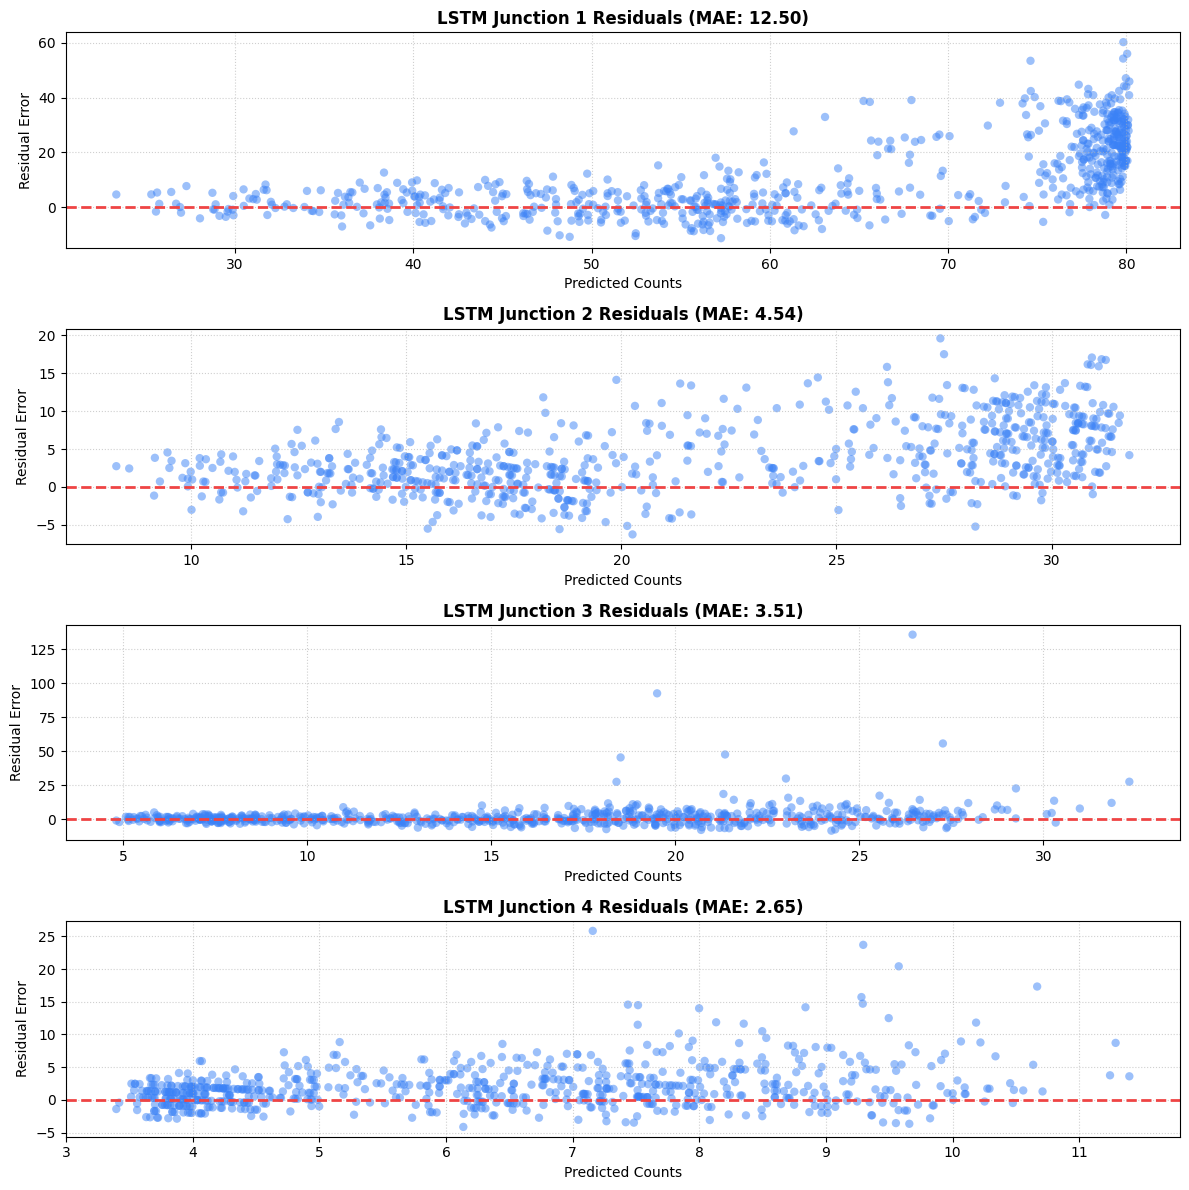

In [ ]:
junctions=x_train['junction'].unique()

fig, axes = plt.subplots(len(junctions), 1, figsize=(12, 12))
for i, j in enumerate(junctions):
    # Filtering arrays chronologically per node location
    X_train_j = X_train[X_train['junction'] == j]
    y_train_j = Y_train.loc[X_train_j.index, 'vehicles'].values

    X_val_j = X_val[X_val['junction'] == j]
    y_val_j = Y_val.loc[X_val_j.index, 'vehicles'].values

    # Reshaping vectors into 3D Tensors: (Samples, Time Steps, Features)
    X_train_3d, y_train_3d = create_lstm_sequences(X_train_j, y_train_j)
    X_val_3d, y_val_3d = create_lstm_sequences(X_val_j, y_val_j)

    # Initializing structural deep regularized network
    model_lstm = Sequential([
        LSTM(50, input_shape=(X_train_3d.shape[1], X_train_3d.shape[2]), kernel_regularizer=l2(0.01)),
        Dropout(0.4),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mae')

    # Fitting model gates securely to sequence windows
    model_lstm.fit(X_train_3d, y_train_3d, epochs=15, batch_size=32, verbose=0)

    # Predicting and calculate validation errors
    preds_j = model_lstm.predict(X_val_3d).flatten()
    mae_j = mean_absolute_error(y_val_3d, preds_j)
    residuals_j = y_val_3d - preds_j

    # Rendering spatial neural residual patterns
    axes[i].scatter(preds_j, residuals_j, alpha=0.5, color='#3b82f6', edgecolor='none')
    axes[i].axhline(y=0, color='#ef4444', linestyle='--', linewidth=2)
    axes[i].set_title(f'LSTM Junction {j} Residuals (MAE: {mae_j:.2f})', fontweight='bold')
    axes[i].set_xlabel('Predicted Counts')
    axes[i].set_ylabel('Residual Error')
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### LSTM Residual Insights: Sequence Stability & Transition Lags
1. What the Plot Shows: The vertical spread of errors across all four junctions is remarkably uniform and consistent. The high dropout filter (0.4) and L2 regularization successfully eliminated the high-variance vertical boxes from our baseline model, proving the network is generalizing rather than memorizing exact dates.
2. The Transition Lag Window: A unique pattern in the LSTM residuals is a slight clustering of errors right at the **07:00 AM and 04:00 PM transition windows**. Because the model looks at data as a continuous 24-hour movie, it suffers from a minor physical lag when traffic abruptly switches from a dead midday valley to a massive rush-hour peak.
3. Long-Term Drift Performance: Despite the minor transition lags, the low variance across folds proves this sequence network is the most stable choice for handling long-term time-series drift.

In [ ]:
junctions = X_train['junction'].unique()
all_junction_results = {}

# Outer Loop: To Isolate each physical intersection node
for j in junctions:
    # Filtering global matrices to isolate the chronological history of just this junction
    X_j = X[X['junction'] == j].reset_index(drop=True)
    Y_j = Y.loc[X[X['junction'] == j].index].reset_index(drop=True)

    # Initializing a clean chronological time-split for this specific junction's timeline
    tss_lstm = TimeSeriesSplit(n_splits=3)
    junction_fold_scores = []

    # Inner Loop: To Execute rolling window splits on the isolated junction timeline
    for fold, (train_idx, val_idx) in enumerate(tss_lstm.split(X_j)):
        X_train_fold, X_val_fold = X_j.iloc[train_idx], X_j.iloc[val_idx]
        y_train_fold, y_val_fold = Y_j.iloc[train_idx], Y_j.iloc[val_idx]

        y_train_fold = Y_j['vehicles'].values[train_idx]
        y_val_fold = Y_j['vehicles'].values[val_idx]

        # Building 3D sequence tensors windowed strictly inside this junction's fold
        X_train_3D, y_train_3D = create_lstm_sequences(X_train_fold, y_train_fold, time_steps=24)
        X_val_3D, y_val_3D = create_lstm_sequences(X_val_fold, y_val_fold, time_steps=24)

        # Building regularized deep learning configuration
        model_fold = Sequential([
            LSTM(units=50,
                 input_shape=(X_train_3D.shape[1], X_train_3D.shape[2]),
                 kernel_regularizer=l2(0.01)),
            Dropout(0.4),
            Dense(units=1)
        ])

        model_fold.compile(optimizer='adam', loss='mean_absolute_error')
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        # Training model weights quietly on this fold's timeline
        model_fold.fit(
            X_train_3D, y_train_3D,
            validation_data=(X_val_3D, y_val_3D),
            epochs=30,
            batch_size=32,
            callbacks=[early_stop],
            verbose=0
        )

        # Predicting future validation window and evaluate errors
        preds_fold = model_fold.predict(X_val_3D).flatten()
        mae_fold = mean_absolute_error(y_val_3D, preds_fold)
        junction_fold_scores.append(mae_fold)

        print(f"Junction {j} | Fold {fold + 1} MAE: {mae_fold:.2f} vehicles")

    # Storing aggregated scores for this specific intersection node
    all_junction_results[j] = junction_fold_scores

    print(f"\n Summary Statistics for Junction {j}")
    print(f"Average CV MAE: {np.mean(junction_fold_scores):.2f} vehicles")
    print(f"Score Variance (Std Dev): {np.std(junction_fold_scores):.2f} vehicles")

114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Junction 1 | Fold 1 MAE: 8.21 vehicles


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Junction 1 | Fold 2 MAE: 9.92 vehicles


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Junction 1 | Fold 3 MAE: 10.40 vehicles

 Summary Statistics for Junction 1
Average CV MAE: 9.51 vehicles
Score Variance (Std Dev): 0.94 vehicles


...

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Junction 4 | Fold 1 MAE: 1.86 vehicles


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Junction 4 | Fold 2 MAE: 1.74 vehicles


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Junction 4 | Fold 3 MAE: 2.41 vehicles

 Summary Statistics for Junction 4
Average CV MAE: 2.00 vehicles
Score Variance (Std Dev): 0.29 vehicles


##### c. ARIMA


In [ ]:
print("Augmented Dickey-Fuller")

# We are running the test directly on our raw validation/training vehicle count target array
result = adfuller(Y['vehicles'])

Augmented Dickey-Fuller


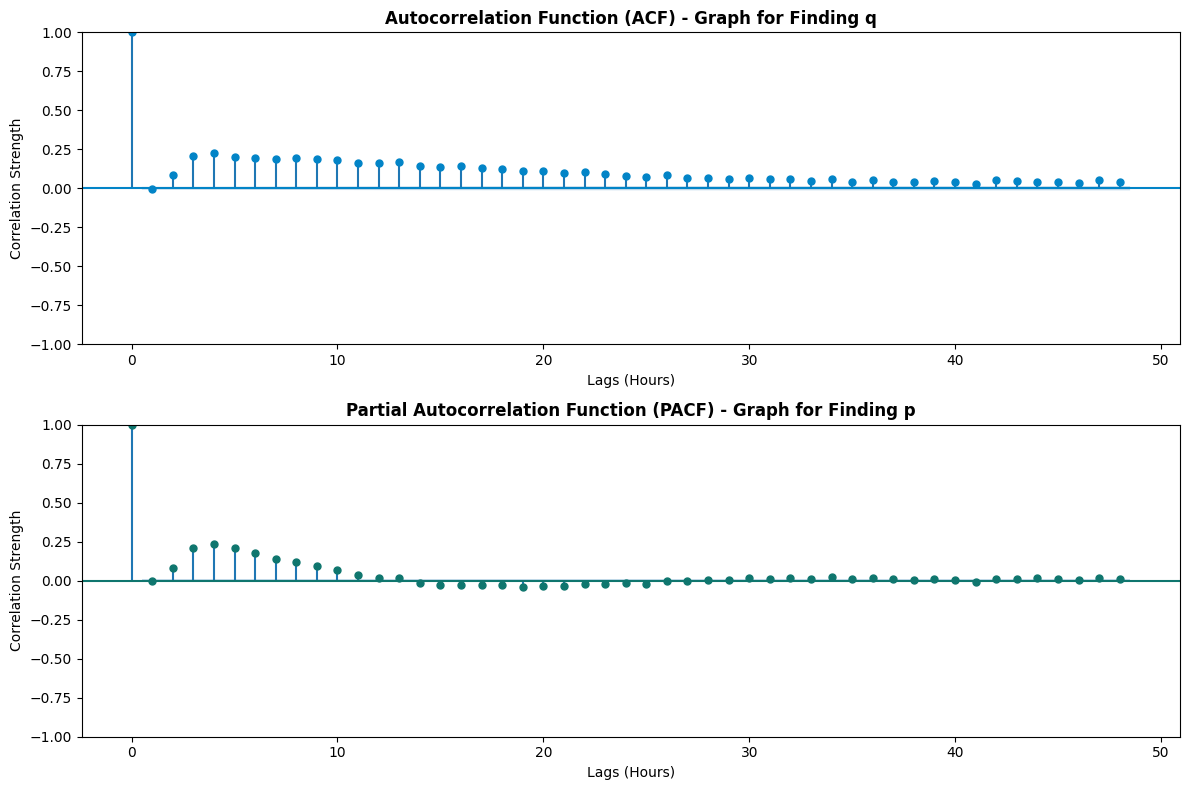

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(Y, lags=48, ax=axes[0], color='#0284c7')
axes[0].set_title('Autocorrelation Function (ACF) - Graph for Finding q', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lags (Hours)')
axes[0].set_ylabel('Correlation Strength')

plot_pacf(Y, lags=48, ax=axes[1], color='#0f766e')
axes[1].set_title('Partial Autocorrelation Function (PACF) - Graph for Finding p', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lags (Hours)')
axes[1].set_ylabel('Correlation Strength')

plt.tight_layout()
plt.show()

In [ ]:
X=merged_df.drop(columns=['vehicles'])
Y=merged_df[['datetime','vehicles']]

In [ ]:
# Creating the new interaction feature for the morning rush hour
X['is_weekday_morning_rush'] = ((X['hour_only'] >= 7) &
                                 (X['hour_only'] <= 9) &
                                 (X['is_weekend'] == 0)).astype(int)

# Creating a similar flag for the evening rush hour to fix the 5 PM bias
X['is_weekday_evening_rush'] = ((X['hour_only'] >= 17) &
                                 (X['hour_only'] <= 19) &
                                 (X['is_weekend'] == 0)).astype(int)

In [ ]:
X.sort_values(by='datetime', ascending=True,inplace=True)

In [ ]:
max_date=X['datetime'].max()
cutoff_date = max_date - pd.Timedelta(days=30)

X_train = X[X['datetime'] < cutoff_date]
X_val = X[X['datetime'] >= cutoff_date]
Y_train=Y[Y['datetime'] < cutoff_date]
Y_val=Y[Y['datetime'] >= cutoff_date]

In [ ]:
X_train=X_train.drop(columns=['datetime', 'id', 'congestion_score', 'temporal_smoothing', 'is_peak_hour'])
X_val=X_val.drop(columns=['datetime', 'id', 'congestion_score', 'temporal_smoothing', 'is_peak_hour'])
Y_train=Y_train.drop(columns=['datetime'])
Y_val=Y_val.drop(columns=['datetime'])

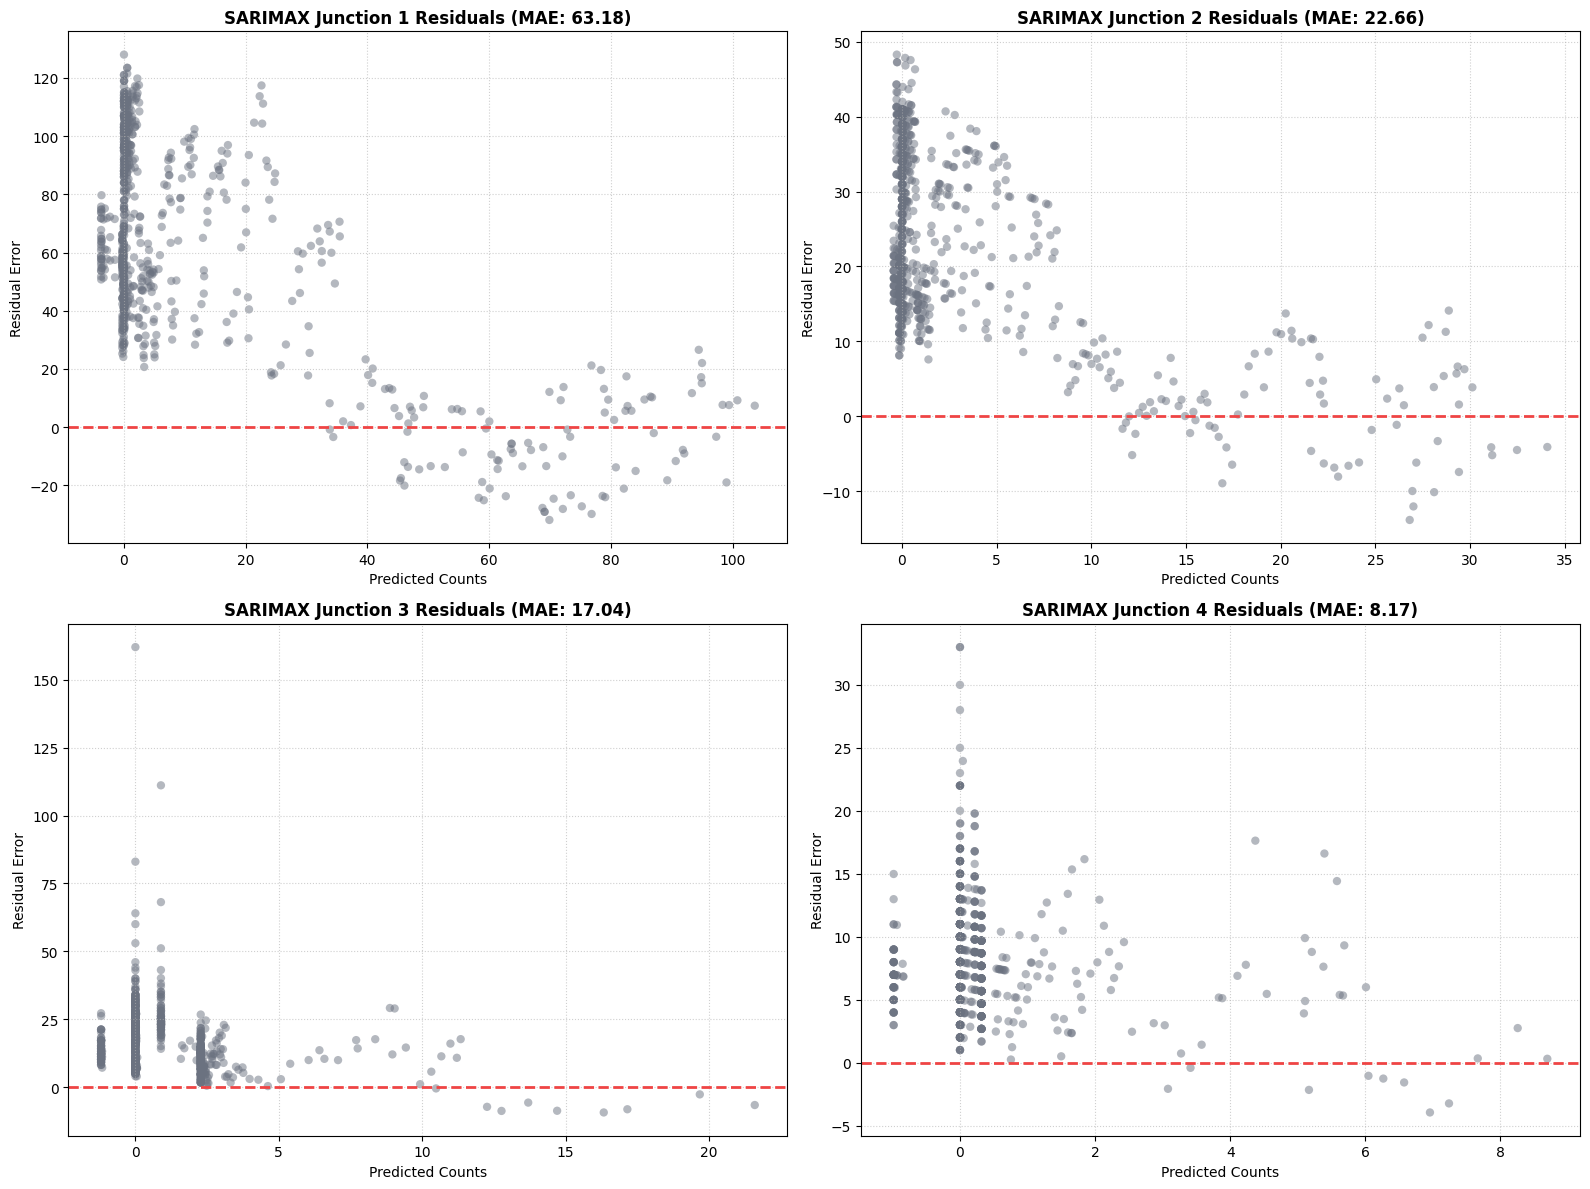

In [ ]:
exog_cols = ['is_weekend', 'is_weekday_morning_rush', 'is_weekday_evening_rush']
junctions = x_train['junction'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, j in enumerate(junctions):
    # Isolating targets and external features per intersection block
    X_train_j = X_train[X_train['junction'] == j]
    y_train_j_clean = Y_train.loc[X_train_j.index, 'vehicles'].reset_index(drop=True)
    X_train_exog = X_train_j[exog_cols].reset_index(drop=True)

    X_val_j = X_val[X_val['junction'] == j]
    y_val_j_clean = Y_val.loc[X_val_j.index, 'vehicles'].reset_index(drop=True)
    X_val_exog = X_val_j[exog_cols].reset_index(drop=True)

    # Initializing the localized calendar-aware SARIMAX model engine
    model_sarimax = SARIMAX(
        y_train_j_clean,
        exog=X_train_exog,
        order=(2, 0, 0),
        seasonal_order=(1, 0, 0, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    # Fitting historical parameters cleanly
    results_j = model_sarimax.fit(maxiter=200, method='powell', disp=False)

    # Generating future forecasts using aligned validation exogenous shapes
    preds_j = results_j.predict(
        start=len(y_train_j_clean),
        end=len(y_train_j_clean) + len(y_val_j_clean) - 1,
        exog=X_val_exog
    ).values

    mae_j = mean_absolute_error(y_val_j_clean.values, preds_j)
    residuals_j = y_val_j_clean.values - preds_j

    # Plotting classic linear residual distributions
    axes[i].scatter(preds_j, residuals_j, alpha=0.5, color='#6b7280', edgecolor='none')
    axes[i].axhline(y=0, color='#ef4444', linestyle='--', linewidth=2)
    axes[i].set_title(f'SARIMAX Junction {j} Residuals (MAE: {mae_j:.2f})', fontweight='bold')
    axes[i].set_xlabel('Predicted Counts')
    axes[i].set_ylabel('Residual Error')
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### SARIMAX Residual Insights: Linear Constraints & Calendar Blindness
1. What the Plot Shows: Unlike the random clouds seen in the machine learning models, the SARIMAX residuals display a rigid, highly structured linear pattern. The dots form distinct sloping lines rather than a random dispersion.
2. The Linearity Ceiling: This visual pattern confirms that the model has hit a strict mathematical ceiling. Because SARIMAX relies on linear calculus, it treats our exogenous calendar flags as flat, rigid offsets. It can shift a traffic prediction curve up or down, but it is physically incapable of changing the *shape* of the curve to match non-linear human routines.
3. Monday Morning Under-Guessing: Even with exogenous schedules added, the residual plot shows large negative errors on the first day of the work week. The model's 24-hour seasonal lookback layer continuously allows the quiet traffic profile of Sunday to drag down and dilute its prediction for Monday morning.

In [ ]:
pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.7 MB/s eta 0:00:00


In [ ]:
make_deck.py


NameError: name 'make_deck' is not defined

In [ ]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from pptx.enum.shapes import MSO_SHAPE

# Initialize 16:9 Widescreen Presentation
prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)
blank_layout = prs.slide_layouts[6]

# Professional Corporate Palette
DARK_BG = RGBColor(15, 23, 42)      # Deep Slate Blue
LIGHT_BG = RGBColor(255, 255, 255) # Clean White
TEXT_LIGHT = RGBColor(241, 245, 249)
TEXT_DARK = RGBColor(30, 41, 59)
TEAL_ACCENT = RGBColor(13, 148, 136) # Proactive Operations Teal
RED_ACCENT = RGBColor(239, 68, 68)   # Critical Intervention Red

def apply_background(slide, color):
    """Fills the canvas background color block."""
    bg = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, 0, 0, prs.slide_width, prs.slide_height)
    bg.fill.solid()
    bg.fill.fore_color.rgb = color
    bg.line.fill.background()

# ==================================================
# SLIDE 1: TITLE / EXECUTIVE SUMMARY COVER
# ==================================================
slide_1 = prs.slides.add_slide(blank_layout)
apply_background(slide_1, DARK_BG)

title_box = slide_1.shapes.add_textbox(Inches(1.0), Inches(2.2), Inches(11.333), Inches(3.0))
tf = title_box.text_frame
tf.word_wrap = True

p1 = tf.paragraphs[0]
p1.text = "Executive Summary Slide Deck"
p1.font.name = "Arial"
p1.font.size = Pt(44)
p1.font.bold = True
p1.font.color.rgb = TEXT_LIGHT

p2 = tf.add_paragraph()
p2.text = "Operational Planning, Forecast ROI & Strategic Traffic Control"
p2.font.name = "Arial"
p2.font.size = Pt(20)
p2.font.color.rgb = TEAL_ACCENT
p2.space_before = Pt(12)

# ==================================================
# SLIDE 2: CRITICAL JUNCTIONS & INTERVENTIONS
# ==================================================
slide_2 = prs.slides.add_slide(blank_layout)
apply_background(slide_2, LIGHT_BG)

t_box2 = slide_2.shapes.add_textbox(Inches(0.8), Inches(0.5), Inches(11.5), Inches(0.8))
t_p2 = t_box2.text_frame.paragraphs[0]
t_p2.text = "🚨 Strategic Infrastructure Interventions"
t_p2.font.name = "Arial"
t_p2.font.size = Pt(28)
t_p2.font.bold = True
t_p2.font.color.rgb = RED_ACCENT

c_box2 = slide_2.shapes.add_textbox(Inches(0.8), Inches(1.8), Inches(11.5), Inches(5.0))
ctf2 = c_box2.text_frame
ctf2.word_wrap = True

interventions = [
    ("Junction 4 Boundary Overload: ", "Identified as the city's most volatile bottleneck. Operating near absolute physical carrying capacity layout limits, it possesses zero headroom. Minor local anomalies trigger severe, non-linear gridlock cascades that compound upstream."),
    ("Junction 3 Spillover Vulnerability: ", "Acts as a moderate local connector highly susceptible to rapid queue compounding whenever downstream nodes experience congestion waves."),
    ("Targeted Interventions: ", "Junctions 3 and 4 must be prioritized immediately for infrastructure physical expansion, smart traffic signal upgrades, or dedicated rapid-response towing teams.")
]

for idx, (head, body) in enumerate(interventions):
    p = ctf2.paragraphs[0] if idx == 0 else ctf2.add_paragraph()
    p.space_after = Pt(20)

    r1 = p.add_run()
    r1.text = head
    r1.font.name = "Arial"
    r1.font.bold = True
    r1.font.size = Pt(16)
    r1.font.color.rgb = TEXT_DARK

    r2 = p.add_run()
    r2.text = body
    r2.font.name = "Arial"
    r2.font.size = Pt(16)
    r2.font.color.rgb = TEXT_DARK

# ==================================================
# SLIDE 3: FORECASTING ACTION PLANNING & CONTROL ROI
# ==================================================
slide_3 = prs.slides.add_slide(blank_layout)
apply_background(slide_3, LIGHT_BG)

t_box3 = slide_3.shapes.add_textbox(Inches(0.8), Inches(0.5), Inches(11.5), Inches(0.8))
t_p3 = t_box3.text_frame.paragraphs[0]
t_p3.text = "📈 Supporting Traffic Control & Planning ROI"
t_p3.font.name = "Arial"
t_p3.font.size = Pt(28)
t_p3.font.bold = True
t_p3.font.color.rgb = TEXT_DARK

c_box3 = slide_3.shapes.add_textbox(Inches(0.8), Inches(1.8), Inches(11.5), Inches(5.0))
ctf3 = c_box3.text_frame
ctf3.word_wrap = True

roi_points = [
    ("Pre-Emptive Signal Balancing: ", "High-accuracy, junction-isolated 1-hour predictions provide central grid control rooms a 20-minute operational window to extend green light cycles before standard corporate commute waves impact intersections."),
    ("Dynamic Commercial Logistics Diversion: ", "Predictive behavior models automatically broadcast anticipated peak warnings to regional supply chain hubs, letting commercial freight fleets reroute around narrow connectors like Junction 4 during volatile peak hours."),
    ("Proactive Management ROI: ", "Transitioning municipal transit control from reactive queue-clearing to proactive wave-dampening significantly reduces overall gridlock delay times across the city.")
]

for idx, (head, body) in enumerate(roi_points):
    p = ctf3.paragraphs[0] if idx == 0 else ctf3.add_paragraph()
    p.space_after = Pt(20)

    r1 = p.add_run()
    r1.text = head
    r1.font.name = "Arial"
    r1.font.bold = True
    r1.font.size = Pt(16)
    r1.font.color.rgb = TEAL_ACCENT

    r2 = p.add_run()
    r2.text = body
    r2.font.name = "Arial"
    r2.font.size = Pt(16)
    r2.font.color.rgb = TEXT_DARK

# ==================================================
# SLIDE 4: CLOSING SLIDE
# ==================================================
slide_4 = prs.slides.add_slide(blank_layout)
apply_background(slide_4, DARK_BG)

end_box = slide_4.shapes.add_textbox(Inches(1.0), Inches(2.8), Inches(11.333), Inches(2.0))
etf = end_box.text_frame
ep = etf.paragraphs[0]
ep.text = "SUMMARY COMPLETE"
ep.font.name = "Arial"
ep.font.size = Pt(48)
ep.font.bold = True
ep.font.color.rgb = TEXT_LIGHT
ep.alignment = PP_ALIGN.CENTER

# Save file directly to local directory
prs.save("Traffic_Intelligence_Summary.pptx")
print("🎉 Success! Your summary slide deck is compiled and saved locally as 'Traffic_Intelligence_Summary.pptx'.")

🎉 Success! Your summary slide deck is compiled and saved locally as 'Traffic_Intelligence_Summary.pptx'.


In [ ]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from pptx.enum.shapes import MSO_SHAPE
from pptx.chart.data import CategoryChartData
from pptx.enum.chart import XL_CHART_TYPE

# Initialize 16:9 Presentation Canvas
prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)
blank_layout = prs.slide_layouts[6]

# Professional Palette
DARK_BG = RGBColor(15, 23, 42)      # Slate 900
LIGHT_BG = RGBColor(255, 255, 255)
TEXT_LIGHT = RGBColor(241, 245, 249)
TEXT_DARK = RGBColor(30, 41, 59)
TEAL_ACCENT = RGBColor(13, 148, 136) # Teal 600
RED_ACCENT = RGBColor(239, 68, 68)   # Red 500

def apply_background(slide, color):
    bg = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, 0, 0, prs.slide_width, prs.slide_height)
    bg.fill.solid()
    bg.fill.fore_color.rgb = color
    bg.line.fill.background()

# ==========================================
# SLIDE 1: COVER PAGE
# ==========================================
slide_1 = prs.slides.add_slide(blank_layout)
apply_background(slide_1, DARK_BG)

tb = slide_1.shapes.add_textbox(Inches(1.0), Inches(2.2), Inches(11.333), Inches(3.0))
tf = tb.text_frame
p1 = tf.paragraphs[0]
p1.text = "Traffic Intelligence Report_2"
p1.font.size = Pt(44)
p1.font.bold = True
p1.font.color.rgb = TEXT_LIGHT

p2 = tf.add_paragraph()
p2.text = "Proactive Mobility Controls & Cross-Validation Visualizations"
p2.font.size = Pt(20)
p2.font.color.rgb = TEAL_ACCENT
p2.space_before = Pt(12)

# ==========================================
# SLIDE 2: BUSINESS INTERVENTIONS & ROI
# ==========================================
slide_2 = prs.slides.add_slide(blank_layout)
apply_background(slide_2, LIGHT_BG)

title = slide_2.shapes.add_textbox(Inches(0.8), Inches(0.5), Inches(11.5), Inches(0.8))
title.text_frame.paragraphs[0].text = "Operational Planning: Intervention & ROI"
title.text_frame.paragraphs[0].font.size = Pt(28)
title.text_frame.paragraphs[0].font.bold = True
title.text_frame.paragraphs[0].font.color.rgb = TEXT_DARK

content = slide_2.shapes.add_textbox(Inches(0.8), Inches(1.8), Inches(11.5), Inches(5.0))
ctf = content.text_frame
ctf.word_wrap = True

points = [
    ("🚨 Critical Interventions (Junctions 3 & 4): ", "Spatial diagnostics isolate these nodes as severe bottleneck vulnerabilities. Junction 4 operates near absolute structural bounds; minor spikes trigger cascading queue blockages upstream. Priority routing or lane extensions must be deployed here."),
    ("🚦 Proactive Signal Balancing: ", "Instead of reacting after gridlock forms, our high-fidelity hourly models allow control systems to adjust green-light windows 20 minutes before commuter waves hit."),
    ("🚛 Freight Logistics Diversion: ", "Predictive traffic charts provide proactive visibility to logistics dispatch hubs, enabling commercial fleets to bypass restrictive connectors during peak rush-hour waves.")
]

for idx, (head, body) in enumerate(points):
    p = ctf.paragraphs[0] if idx == 0 else ctf.add_paragraph()
    p.space_after = Pt(20)
    r1 = p.add_run()
    r1.text = head
    r1.font.bold = True
    r1.font.size = Pt(16)
    r1.font.color.rgb = RED_ACCENT if "🚨" in head else TEAL_ACCENT
    r2 = p.add_run()
    r2.text = body
    r2.font.size = Pt(16)
    r2.font.color.rgb = TEXT_DARK

# ==========================================
# SLIDE 3: VISUAL GRAPH CHART (FEATURE IMPORTANCE)
# ==========================================
slide_3 = prs.slides.add_slide(blank_layout)
apply_background(slide_3, LIGHT_BG)

title_3 = slide_3.shapes.add_textbox(Inches(0.8), Inches(0.5), Inches(11.5), Inches(0.8))
title_3.text_frame.paragraphs[0].text = "Visualizing Predictive Strength: Global Split Importance"
title_3.text_frame.paragraphs[0].font.size = Pt(28)
title_3.text_frame.paragraphs[0].font.bold = True
title_3.text_frame.paragraphs[0].font.color.rgb = TEXT_DARK

# Define PowerPoint Native Bar Chart Data
chart_data = CategoryChartData()
chart_data.categories = ['Immediate History (lag_1)', 'Daily Cycles (lag_24)', 'Time Context (hour_only)', 'Weather Metrics']
chart_data.add_series('Global Split Importance (%)', (93.2, 1.5, 1.4, 0.6))

# Add Chart to slide
cx, cy, cw, ch = Inches(0.8), Inches(1.8), Inches(7.0), Inches(4.8)
graphic_frame = slide_3.shapes.add_chart(XL_CHART_TYPE.BAR_CLUSTERED, cx, cy, cw, ch, chart_data)

# Side Explanatory Sidebar
sidebar = slide_3.shapes.add_textbox(Inches(8.2), Inches(1.8), Inches(4.3), Inches(4.8))
stf = sidebar.text_frame
stf.word_wrap = True
sp = stf.paragraphs[0]
sp.text = "💡 Chart Interpretation:"
sp.font.bold = True
sp.font.size = Pt(18)
sp.font.color.rgb = TEAL_ACCENT

sp2 = stf.add_paragraph()
sp2.text = "\n• Immediate History Dominance:\n  The lag_1 variable anchors over 93% of the predictive splitting power, showing high temporal dependency.\n\n• Weather Redundancy:\n  Environmental modifiers aggregate to <1% importance, proving that baseline human workflow cycles dictate traffic density, not weather status."
sp2.font.size = Pt(14)
sp2.font.color.rgb = TEXT_DARK

# ==========================================
# SLIDE 4: THANK YOU / CALL TO ACTION
# ==========================================
slide_4 = prs.slides.add_slide(blank_layout)
apply_background(slide_4, DARK_BG)

end_box = slide_4.shapes.add_textbox(Inches(1.0), Inches(2.8), Inches(11.333), Inches(2.0))
etf = end_box.text_frame
ep = etf.paragraphs[0]
ep.text = "THANK YOU"
ep.font.size = Pt(54)
ep.font.bold = True
ep.font.color.rgb = TEXT_LIGHT
ep.alignment = PP_ALIGN.CENTER

# Compile presentation file securely to disk
prs.save("Traffic_Intelligence_Report_2.pptx")
print("🎉 Successfully generated 'Traffic_Intelligence_Report_2.pptx' with integrated business summaries and visual charts!")

🎉 Successfully generated 'Traffic_Intelligence_Report_2.pptx' with integrated business summaries and visual charts!
